# ListenBrainz Popularity Prediction

Predict which artists and tracks will reach **≥95th growth percentile** over upcoming 7-day and 30-day windows.

**Models**: XGBoost (classification + regression) and LSTM (PyTorch)  
**Data**: RDS Postgres → PySpark feature engineering → pandas → model training  
**Scope**: Separate artist and track models

| Phase | Description |
|-------|-------------|
| 1 | Data loading & feature engineering (Spark JDBC) |
| 2 | XGBoost classifier + regressor |
| 3 | LSTM sequence model (PyTorch) |
| 4 | Evaluation & comparison |

**Before running, make sure:**

- SSH tunnel is active (localhost:5433 → RDS)
- .env has fresh AWS credentials
- Required packages are installed: xgboost, shap, torch, scikit-learn, matplotlib

In [1]:
import importlib
import sys
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Add parent dir so we can import project modules
sys.path.insert(0, str(Path.cwd().parent))

import utils
importlib.reload(utils)
from utils import load_db_credentials

print("Imports OK")

Imports OK


In [2]:
from dotenv import load_dotenv
import json

import psycopg2
import boto3

env_path = Path.cwd().parent.parent / ".env"
print(f"Loading env from: {env_path}  (exists={env_path.exists()})")
load_dotenv(dotenv_path=env_path, override=True)

# Reset boto3 session so it picks up fresh env vars
boto3.DEFAULT_SESSION = None

creds = load_db_credentials()


def _probe_db(c):
    conn = None
    try:
        conn = psycopg2.connect(
            host=c["host"],
            port=int(c["port"]),
            dbname=c["dbname"],
            user=c["user"],
            password=c["password"],
            connect_timeout=6,
            sslmode="prefer",
        )
        with conn.cursor() as cur:
            cur.execute("SELECT current_user, current_database();")
            current_user, current_db = cur.fetchone()
        return True, f"connected as {current_user} to {current_db}"
    except Exception as e:
        return False, str(e)
    finally:
        if conn is not None:
            conn.close()


def _candidate_creds(base):
    candidates = [dict(base)]
    is_loopback = str(base["host"]).strip('"') in {"127.0.0.1", "localhost"}

    # Common local setup uses an SSH tunnel on 5433.
    if is_loopback and int(base["port"]) == 5432:
        alt = dict(base)
        alt["port"] = 5433
        candidates.append(alt)

    # If secret includes username, try it as a fallback.
    secret_username = None
    try:
        sm = boto3.client("secretsmanager", region_name=utils._AWS_REGION)
        secret_str = sm.get_secret_value(SecretId=utils._SECRET_ARN)["SecretString"]
        secret_obj = json.loads(secret_str)
        secret_username = secret_obj.get("username") or secret_obj.get("user")
    except Exception:
        pass

    if secret_username and secret_username != base["user"]:
        alt_user = dict(base)
        alt_user["user"] = secret_username
        candidates.append(alt_user)

        if is_loopback and int(base["port"]) == 5432:
            alt_user_port = dict(alt_user)
            alt_user_port["port"] = 5433
            candidates.append(alt_user_port)

    deduped = []
    seen = set()
    for c in candidates:
        key = (str(c["host"]), int(c["port"]), str(c["dbname"]), str(c["user"]))
        if key not in seen:
            seen.add(key)
            deduped.append(c)
    return deduped


selected = None
errors = []
for cand in _candidate_creds(creds):
    ok, msg = _probe_db(cand)
    if ok:
        selected = cand
        print(
            f"DB probe OK: {cand['host']}:{cand['port']}/{cand['dbname']} "
            f"as {cand['user']} ({msg})"
        )
        break
    errors.append(
        f"{cand['host']}:{cand['port']}/{cand['dbname']} as {cand['user']} -> {msg}"
    )

if selected is None:
    print("Database probe failed for all candidate credentials:")
    for err in errors:
        print(f"  - {err}")

    hints = []
    if any("127.0.0.1:5433" in err and "Connection refused" in err for err in errors):
        hints.append("Start your SSH tunnel to RDS on local port 5433.")
    if any('role "postgres" does not exist' in err for err in errors):
        hints.append("Set PGUSER in project/.env to a valid role for this DB.")

    # Ensure stale Spark state from prior runs cannot leak into later cells.
    try:
        old_spark = globals().get("spark", None)
        if old_spark is not None:
            old_spark.stop()
    except Exception:
        pass
    spark = None

    creds = None
    raise RuntimeError(
        "Could not authenticate to Postgres. " + " ".join(hints)
    )

creds = selected
print(f"Using DB: {creds['host']}:{creds['port']}/{creds['dbname']} as {creds['user']}")

Loading env from: /Users/didiermunezero/Documents/NU/Junior/DE 300/de300-2026wi-stall/project/.env  (exists=True)
DB probe OK: 127.0.0.1:5433/postgres as postgres (connected as postgres to postgres)
Using DB: 127.0.0.1:5433/postgres as postgres


In [3]:
# DATABASE CONNECTION DIAGNOSTIC
print("\n" + "="*70)
print("📊 DATABASE CONNECTION INFO")
print("="*70)
print(f"Host:     {creds['host']}")
print(f"Port:     {creds['port']}")
print(f"Database: {creds['dbname']}")
print(f"User:     {creds['user']}")
print()
if creds['host'] in ['127.0.0.1', 'localhost']:
    print("🏠 CONNECTION TYPE: LOCAL")
    if int(creds['port']) == 5433:
        print("   (SSH tunnel to RDS on port 5433)")
    else:
        print("   (Direct local PostgreSQL on port 5432)")
else:
    print("☁️  CONNECTION TYPE: RDS (Remote)")
    print(f"   (Direct connection to {creds['host']})")
print("="*70 + "\n")


📊 DATABASE CONNECTION INFO
Host:     127.0.0.1
Port:     5433
Database: postgres
User:     postgres

🏠 CONNECTION TYPE: LOCAL
   (SSH tunnel to RDS on port 5433)



## Phase 1 — Data Loading & Feature Engineering

Load `artist_daily_stats` / `track_daily_stats` joined with raw listen counts via Spark JDBC, engineer momentum/velocity/lag features, build forward-looking target labels, and convert to pandas with a temporal train/test split.

In [4]:
import os
from pathlib import Path

# Workaround for Spark on Windows: set HADOOP_HOME to avoid winutils.exe requirement
# Create a dummy hadoop/bin directory if it doesn't exist
hadoop_home = Path.home() / ".hadoop"
hadoop_bin = hadoop_home / "bin"
hadoop_bin.mkdir(parents=True, exist_ok=True)

# Point HADOOP_HOME to this directory
os.environ["HADOOP_HOME"] = str(hadoop_home)
os.environ["hadoop.home.dir"] = str(hadoop_home)

print(f"Set HADOOP_HOME to: {hadoop_home}")

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
from pyspark import SparkContext

if not globals().get("creds"):
    raise RuntimeError("Run Cell 4 successfully first so valid DB credentials are loaded into `creds`.")


def _reset_spark_state():
    """Clear stale Spark/Py4J state so getOrCreate can start a fresh JVM."""
    try:
        old_spark = globals().get("spark", None)
        if old_spark is not None:
            old_spark.stop()
    except Exception:
        pass

    # Drop static Spark session/context pointers.
    SparkSession._instantiatedSession = None
    SparkSession._activeSession = None
    SparkContext._active_spark_context = None

    # Drop dead Py4J gateway/jvm handles so Spark can relaunch them.
    gateway = getattr(SparkContext, "_gateway", None)
    if gateway is not None:
        try:
            gateway.close()
        except Exception:
            pass
    SparkContext._gateway = None
    SparkContext._jvm = None

    # If these are set, PySpark will try to reconnect to a fixed (possibly dead) gateway port.
    os.environ.pop("PYSPARK_GATEWAY_PORT", None)
    os.environ.pop("PYSPARK_GATEWAY_SECRET", None)


def _build_spark_session():
    return (
        SparkSession.builder
        .master("local[*]")
        .appName("ListenBrainz Popularity")
        .config("spark.jars.packages", "org.postgresql:postgresql:42.7.1")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.session.timeZone", "UTC")
        .getOrCreate()
    )


_reset_spark_state()
spark = _build_spark_session()

jdbc_url = f"jdbc:postgresql://{creds['host']}:{creds['port']}/{creds['dbname']}"
jdbc_props = {
    "user": creds["user"],
    "password": creds["password"],
    "driver": "org.postgresql.Driver",
}

print(
    f"Spark {spark.version} ready — JDBC -> "
    f"{creds['host']}:{creds['port']}/{creds['dbname']} as {creds['user']}"
)

Set HADOOP_HOME to: /Users/didiermunezero/.hadoop


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/10 09:53:28 WARN Utils: Your hostname, Didiers-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.220 instead (on interface en0)
26/03/10 09:53:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/Users/didiermunezero/Documents/NU/Junior/DE%20300/.venv/lib/python3.13/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/didiermunezero/.ivy2.5.2/cache
The jars for the packages stored in: /Users/didiermunezero/.ivy2.5.2/jars
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-9ad10cec-ebbc-4987-85f9-91ac43a2074b;1.0
	confs: [default]
	found org.postgresql#postgresql;42.7.1 in central
	found org.checkerframework#checker-qual;3.41.0 in central
:: resolution report :: resolve 122ms :: artifacts dl 

Spark 4.1.1 ready — JDBC -> 127.0.0.1:5433/postgres as postgres


In [5]:
def load_and_engineer(spark, jdbc_url, jdbc_props, stats_table, listens_table, id_col, min_date=None):
    """
    Load stats + daily listens from Postgres, join, and engineer features.
    
    Parameters
    ----------
    min_date : str, optional
        Filter to rows where day >= min_date (e.g., "2026-01-01")
    
    Returns a Spark DataFrame with all original + new columns.
    """
    stats = spark.read.jdbc(url=jdbc_url, table=stats_table, properties=jdbc_props)
    listens = spark.read.jdbc(url=jdbc_url, table=listens_table, properties=jdbc_props)
    
    # DATE FILTER: Only load recent data to avoid sparse historical records
    if min_date:
        print(f"Filtering data to day >= {min_date}")
        stats = stats.filter(F.col("day") >= min_date)
        listens = listens.filter(F.col("day") >= min_date)
    
    print(f"Loaded {stats.count():,} rows from {stats_table}, {listens.count():,} from {listens_table}")

    # Join to get raw listen_count alongside precomputed stats
    df = stats.join(listens, on=["day", id_col], how="inner")

    # Windows for additional features
    w_id = Window.partitionBy(id_col).orderBy("day")
    w_id_7 = w_id.rowsBetween(-6, 0)
    w_id_30 = w_id.rowsBetween(-29, 0)
    w_first = Window.partitionBy(id_col)

    df = (
        df
        # Momentum: short-term acceleration
        .withColumn("_7d_lag7", F.lag("listen_count_past_7_days", 7).over(w_id))
        .withColumn("momentum_7d", F.col("listen_count_past_7_days") - F.col("_7d_lag7"))
        .withColumn("_30d_lag30", F.lag("listen_count_past_30_days", 30).over(w_id))
        .withColumn("momentum_30d", F.col("listen_count_past_30_days") - F.col("_30d_lag30"))
        # Velocity ratio: short-term vs long-term activity
        .withColumn(
            "velocity_ratio",
            F.when(
                F.col("listen_count_past_30_days") > 0,
                F.col("listen_count_past_7_days") / F.col("listen_count_past_30_days"),
            ).otherwise(None),
        )
        # Lifecycle proxy
        .withColumn("_first_day", F.min("day").over(w_first))
        .withColumn("days_since_first_listen", F.datediff(F.col("day"), F.col("_first_day")))
        # Lag features (for LSTM sequences)
        .withColumn("listen_count_lag_1d", F.lag("listen_count", 1).over(w_id))
        .withColumn("listen_count_lag_7d", F.lag("listen_count", 7).over(w_id))
        # Day of week (0=Mon .. 6=Sun); Spark dayofweek is 1=Sun
        .withColumn("day_of_week", (F.dayofweek("day") + 5) % 7)
        .withColumn("is_weekend", F.when(F.dayofweek("day").isin([1, 7]), 1).otherwise(0))
        # Extra features for better signal quality
        .withColumn("listen_count_ma_7d", F.avg("listen_count").over(w_id_7))
        .withColumn("listen_count_ma_30d", F.avg("listen_count").over(w_id_30))
        .withColumn("listen_count_std_7d", F.stddev_pop("listen_count").over(w_id_7))
        .withColumn("log_listen_count", F.log1p(F.col("listen_count")))
        .withColumn(
            "momentum_ratio_7_30",
            F.col("momentum_7d") / (F.abs(F.col("momentum_30d")) + F.lit(1.0)),
        )
        # Drop helper columns
        .drop("_7d_lag7", "_30d_lag30", "_first_day")
    )

    print(f"Feature-engineered DataFrame: {df.count():,} rows, {len(df.columns)} columns")
    return df

print("load_and_engineer() defined")

load_and_engineer() defined


In [6]:
# CRITICAL FIX: Filter to recent data only (last 2 months from today: 2026-03-09)
# This avoids sparse historical data that creates misleading growth rates
MIN_DATE = "2026-01-01"  # Start of 2026 = ~2 months of data

print(f"Loading data from {MIN_DATE} onward (fixes sparse historical data issue)")

artist_df = load_and_engineer(
    spark, jdbc_url, jdbc_props,
    "artist_daily_stats", "artist_daily_listens", "artist_mbid",
    min_date=MIN_DATE
)
track_df = load_and_engineer(
    spark, jdbc_url, jdbc_props,
    "track_daily_stats", "track_daily_listens", "recording_id",
    min_date=MIN_DATE
)

Loading data from 2026-01-01 onward (fixes sparse historical data issue)
Filtering data to day >= 2026-01-01


Loaded 94,351 rows from artist_daily_stats, 98,587 from artist_daily_listens


Feature-engineered DataFrame: 98,587 rows, 23 columns
Filtering data to day >= 2026-01-01


Loaded 1,892,076 rows from track_daily_stats, 1,956,272 from track_daily_listens


Feature-engineered DataFrame: 1,956,272 rows, 23 columns


In [7]:
def add_targets(df, id_col, threshold=0.95, min_future_counts=None):
    """
    Add forward-looking target labels:
      - is_popular_7d / is_popular_30d
      - future_growth_pctl_7d / future_growth_pctl_30d

    `min_future_counts` controls how strict each horizon is, e.g.:
      {"7d": 7, "30d": 30} for strict labels,
      {"7d": 3, "30d": 7} for sparse entities.
    """
    if min_future_counts is None:
        min_future_counts = {"7d": 7, "30d": 30}

    min_7 = int(min_future_counts.get("7d", 7))
    min_30 = int(min_future_counts.get("30d", 30))

    w_id = Window.partitionBy(id_col).orderBy("day")
    w_fwd_7 = w_id.rowsBetween(1, 7)
    w_fwd_30 = w_id.rowsBetween(1, 30)

    # Forward-looking aggregates
    df = (
        df
        .withColumn("_max_gp_7", F.max("growth_percentile").over(w_fwd_7))
        .withColumn("_max_gp_30", F.max("growth_percentile").over(w_fwd_30))
        .withColumn("_mean_gp_7", F.avg("growth_percentile").over(w_fwd_7))
        .withColumn("_mean_gp_30", F.avg("growth_percentile").over(w_fwd_30))
        .withColumn("_fwd_count_7", F.count("growth_percentile").over(w_fwd_7))
        .withColumn("_fwd_count_30", F.count("growth_percentile").over(w_fwd_30))
    )

    # Flexible per-horizon filtering
    df = df.filter((F.col("_fwd_count_7") >= min_7) & (F.col("_fwd_count_30") >= min_30))

    df = (
        df
        .withColumn("is_popular_7d", F.when(F.col("_max_gp_7") >= threshold, 1).otherwise(0))
        .withColumn("is_popular_30d", F.when(F.col("_max_gp_30") >= threshold, 1).otherwise(0))
        .withColumn("future_growth_pctl_7d", F.col("_mean_gp_7"))
        .withColumn("future_growth_pctl_30d", F.col("_mean_gp_30"))
        .drop("_max_gp_7", "_max_gp_30", "_mean_gp_7", "_mean_gp_30", "_fwd_count_7", "_fwd_count_30")
    )

    n = df.count()
    if n == 0:
        print(
            f"After target labeling ({id_col}): 0 rows remain "
            f"(requirements: 7d>={min_7}, 30d>={min_30})."
        )
        return df

    pos_7 = df.filter(F.col("is_popular_7d") == 1).count()
    pos_30 = df.filter(F.col("is_popular_30d") == 1).count()
    print(f"After target labeling ({id_col}): {n:,} rows")
    print(f"  Required future rows -> 7d:>={min_7}, 30d:>={min_30}")
    print(f"  is_popular_7d:  {pos_7:,} positive ({100 * pos_7 / n:.2f}%)")
    print(f"  is_popular_30d: {pos_30:,} positive ({100 * pos_30 / n:.2f}%)")
    return df

print("add_targets() defined")

add_targets() defined


In [8]:
# DATA QUALITY: Add minimum observation requirements per entity
# Filter out entities with too few data points (cause spurious growth rates)
from pyspark.sql import Window as W

def filter_min_observations(df, id_col, min_days=5):
    """Remove entities with fewer than min_days observations."""
    w_id = W.partitionBy(id_col)
    df = df.withColumn("_obs_count", F.count("day").over(w_id))
    initial = df.count()
    df = df.filter(F.col("_obs_count") >= min_days).drop("_obs_count")
    final = df.count()
    removed = initial - final
    print(f"  Filtered entities with <{min_days} days: removed {removed:,} rows ({100*removed/initial:.1f}%)")
    return df

# Artist data is sparse - require at least 3 observations
artist_df = filter_min_observations(artist_df, "artist_mbid", min_days=3)

# Track data - require at least 5 observations
track_df = filter_min_observations(track_df, "recording_id", min_days=5)

# Now add targets with relaxed requirements (data is already filtered to recent + sufficient obs)
artist_df = add_targets(
    artist_df,
    "artist_mbid",
    threshold=0.95,
    min_future_counts={"7d": 1, "30d": 1},
)

# Focus on 7-day predictions (performed better in your tests)
track_df = add_targets(
    track_df,
    "recording_id",
    threshold=0.95,
    min_future_counts={"7d": 5, "30d": 7},  # Relaxed 30d since 7d is better
)

  Filtered entities with <3 days: removed 41,263 rows (41.9%)


  Filtered entities with <5 days: removed 1,503,503 rows (76.9%)


After target labeling (artist_mbid): 45,027 rows
  Required future rows -> 7d:>=1, 30d:>=1
  is_popular_7d:  5,173 positive (11.49%)
  is_popular_30d: 5,177 positive (11.50%)


After target labeling (recording_id): 55,561 rows
  Required future rows -> 7d:>=5, 30d:>=7
  is_popular_7d:  1,161 positive (2.09%)
  is_popular_30d: 1,190 positive (2.14%)


In [9]:
def _pick_temporal_cutoff(
    pdf,
    target_cols,
    test_days_candidates,
    min_train_rows,
    min_test_rows,
    min_positive_per_target,
):
    """Find the smallest temporal holdout that has enough train rows, test rows, and positives."""
    max_day = pdf["day"].max()
    class_targets = [c for c in target_cols[:2] if c in pdf.columns]

    best_candidate = None
    best_score = (-1, -1, -1, -1, -1)

    for days in test_days_candidates:
        cutoff = max_day - pd.Timedelta(days=int(days))
        train = pdf[pdf["day"] <= cutoff].copy()
        test = pdf[pdf["day"] > cutoff].copy()

        pos_counts = {t: int(test[t].sum()) for t in class_targets}
        min_pos = min(pos_counts.values()) if pos_counts else 0

        meets_train = len(train) >= min_train_rows
        meets_test = len(test) >= min_test_rows
        meets_pos = (min_pos >= min_positive_per_target) if class_targets else True

        candidate = (days, cutoff, train, test, pos_counts, meets_train, meets_test, meets_pos)
        score = (
            int(meets_train),
            int(meets_test),
            int(meets_pos),
            min_pos,
            len(test),
        )

        if score > best_score:
            best_candidate = candidate
            best_score = score

        if meets_train and meets_test and meets_pos:
            return candidate, True

    return best_candidate, False


def spark_to_pandas_split(
    sdf,
    id_col,
    test_days_candidates=(30, 60, 90, 120, 180, 270, 365),
    min_train_rows=50000,
    min_test_rows=5000,
    min_positive_per_target=50,
):
    """
    Convert Spark DF to pandas and do a robust temporal split.
    Chooses a holdout window that tries to satisfy minimum train size, test size, and positives.
    Returns (train_pdf, test_pdf, feature_cols, target_cols).
    """
    target_cols = [
        "is_popular_7d",
        "is_popular_30d",
        "future_growth_pctl_7d",
        "future_growth_pctl_30d",
    ]

    pdf = sdf.toPandas()
    if pdf.empty:
        print(f"Warning: {id_col} dataset is empty after target labeling.")
        empty = pd.DataFrame()
        return empty, empty, [], target_cols

    pdf["day"] = pd.to_datetime(pdf["day"])
    pdf = pdf.sort_values(["day", id_col]).reset_index(drop=True)

    selection, constraints_met = _pick_temporal_cutoff(
        pdf,
        target_cols,
        test_days_candidates,
        min_train_rows,
        min_test_rows,
        min_positive_per_target,
    )

    selected_days, cutoff, train, test, pos_counts, meets_train, meets_test, meets_pos = selection

    if constraints_met:
        print(f"Selected test window for {id_col}: last {selected_days} days (constraints met).")
    else:
        print(f"Selected test window for {id_col}: last {selected_days} days (best fallback).")
        print(
            "  Constraints unmet -> "
            f"min_train_rows={min_train_rows}, min_test_rows={min_test_rows}, "
            f"min_positive_per_target={min_positive_per_target}"
        )
        print(
            f"  Observed -> train_rows={len(train):,}, test_rows={len(test):,}, positives={pos_counts}, "
            f"meets_train={meets_train}, meets_test={meets_test}, meets_pos={meets_pos}"
        )

    # Feature columns: everything except id, day, and targets
    exclude = {id_col, "day"} | set(target_cols)
    feature_cols = [
        c
        for c in pdf.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(pdf[c])
    ]

    if train.empty or test.empty:
        print(
            f"Warning: temporal split for {id_col} produced empty train/test "
            f"(train={len(train)}, test={len(test)})."
        )
    else:
        print(f"Train: {len(train):,} rows ({train['day'].min().date()} - {train['day'].max().date()})")
        print(f"Test:  {len(test):,} rows  ({test['day'].min().date()} - {test['day'].max().date()})")
        print(f"Test positives: {pos_counts}")

    print(f"Features ({len(feature_cols)}): {feature_cols}")
    print(f"Targets: {target_cols}")
    return train, test, feature_cols, target_cols

print("spark_to_pandas_split() defined")

spark_to_pandas_split() defined


In [10]:
art_train, art_test, art_features, target_cols = spark_to_pandas_split(
    artist_df,
    "artist_mbid",
    test_days_candidates=(1, 2, 3, 7, 14, 30, 60),
    min_train_rows=200,
    min_test_rows=100,
    min_positive_per_target=5,
)

trk_train, trk_test, trk_features, _ = spark_to_pandas_split(
    track_df,
    "recording_id",
    test_days_candidates=(1, 2, 3, 7, 14, 30, 60),
    min_train_rows=1000,
    min_test_rows=200,
    min_positive_per_target=5,
)

# Keep full post-target datasets in pandas for robust fallback splits.
art_full_pdf = artist_df.toPandas()
trk_full_pdf = track_df.toPandas()

for pdf_name in ["art_full_pdf", "trk_full_pdf"]:
    globals()[pdf_name]["day"] = pd.to_datetime(globals()[pdf_name]["day"])

print(f"Fallback source snapshots: artist={len(art_full_pdf):,}, track={len(trk_full_pdf):,} rows")

# Stop Spark and clear cached session/context references for safe notebook reruns.
from pyspark.sql import SparkSession
from pyspark import SparkContext

try:
    spark.stop()
except Exception:
    pass

SparkSession._instantiatedSession = None
SparkSession._activeSession = None
SparkContext._active_spark_context = None
spark = None
print("Spark session stopped and cleared.")

26/03/10 09:55:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Selected test window for artist_mbid: last 2 days (constraints met).
Train: 37,942 rows (2026-01-01 - 2026-01-20)
Test:  7,085 rows  (2026-01-21 - 2026-01-22)
Test positives: {'is_popular_7d': 180, 'is_popular_30d': 180}
Features (20): ['growth_percentile', 'cumulative_listen_count', 'listen_count_past_7_days', 'listen_pctl_past_7_days', 'listen_count_past_30_days', 'listen_pctl_past_30_days', 'listen_count', 'momentum_7d', 'momentum_30d', 'velocity_ratio', 'days_since_first_listen', 'listen_count_lag_1d', 'listen_count_lag_7d', 'day_of_week', 'is_weekend', 'listen_count_ma_7d', 'listen_count_ma_30d', 'listen_count_std_7d', 'log_listen_count', 'momentum_ratio_7_30']
Targets: ['is_popular_7d', 'is_popular_30d', 'future_growth_pctl_7d', 'future_growth_pctl_30d']


Selected test window for recording_id: last 1 days (constraints met).
Train: 54,560 rows (2026-01-01 - 2026-01-18)
Test:  1,001 rows  (2026-01-19 - 2026-01-19)
Test positives: {'is_popular_7d': 16, 'is_popular_30d': 16}
Features (20): ['growth_percentile', 'cumulative_listen_count', 'listen_count_past_7_days', 'listen_pctl_past_7_days', 'listen_count_past_30_days', 'listen_pctl_past_30_days', 'listen_count', 'momentum_7d', 'momentum_30d', 'velocity_ratio', 'days_since_first_listen', 'listen_count_lag_1d', 'listen_count_lag_7d', 'day_of_week', 'is_weekend', 'listen_count_ma_7d', 'listen_count_ma_30d', 'listen_count_std_7d', 'log_listen_count', 'momentum_ratio_7_30']
Targets: ['is_popular_7d', 'is_popular_30d', 'future_growth_pctl_7d', 'future_growth_pctl_30d']


Fallback source snapshots: artist=45,027, track=55,561 rows
Spark session stopped and cleared.


In [11]:
# Quick sanity check: NaN rates and class balance
for name, df in [("Artist Train", art_train), ("Track Train", trk_train)]:
    print(f"\n{'='*40}")
    print(f"{name}  ({len(df):,} rows)")
    
    if len(df) == 0:
        print("  Skipping analysis: empty dataset")
        continue
    
    feat_cols = art_features if 'Artist' in name else trk_features
    if len(feat_cols) > 0:
        print(f"  NaN %: {(df[feat_cols].isna().mean() * 100).round(1).to_dict()}")
    
    for t in target_cols[:2]:  # classification targets
        if t in df.columns:
            pos = df[t].mean()
            print(f"  {t}: {100*pos:.1f}% positive")


Artist Train  (37,942 rows)
  NaN %: {'growth_percentile': 0.0, 'cumulative_listen_count': 0.0, 'listen_count_past_7_days': 0.0, 'listen_pctl_past_7_days': 0.0, 'listen_count_past_30_days': 0.0, 'listen_pctl_past_30_days': 0.0, 'listen_count': 0.0, 'momentum_7d': 99.4, 'momentum_30d': 100.0, 'velocity_ratio': 0.0, 'days_since_first_listen': 0.0, 'listen_count_lag_1d': 32.4, 'listen_count_lag_7d': 99.4, 'day_of_week': 0.0, 'is_weekend': 0.0, 'listen_count_ma_7d': 0.0, 'listen_count_ma_30d': 0.0, 'listen_count_std_7d': 0.0, 'log_listen_count': 0.0, 'momentum_ratio_7_30': 100.0}
  is_popular_7d: 13.2% positive
  is_popular_30d: 13.2% positive

Track Train  (54,560 rows)
  NaN %: {'growth_percentile': 0.0, 'cumulative_listen_count': 0.0, 'listen_count_past_7_days': 0.0, 'listen_pctl_past_7_days': 0.0, 'listen_count_past_30_days': 0.0, 'listen_pctl_past_30_days': 0.0, 'listen_count': 0.0, 'momentum_7d': 89.0, 'momentum_30d': 99.9, 'velocity_ratio': 0.0, 'days_since_first_listen': 0.0, 'lis

## Phase 2 — XGBoost Models

Train XGBoost classifiers (binary: popular yes/no) and regressors (continuous growth percentile) for both 7-day and 30-day horizons. Temporal expanding-window CV for hyperparameter selection. SHAP for feature importance.

In [12]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import TimeSeriesSplit
import shap

print("XGBoost + sklearn + SHAP imports OK")

XGBoost + sklearn + SHAP imports OK


In [13]:
def _best_f1_threshold(y_true, scores, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.linspace(0.05, 0.95, 19)

    if len(np.unique(y_true)) < 2:
        return 0.5, float("nan")

    best_th = 0.5
    best_f1 = -1.0
    for th in threshold_grid:
        pred = (scores >= th).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_th = float(th)
    return best_th, best_f1


def _nanmean_or_nan(vals):
    vals = np.array(vals, dtype=float)
    if np.all(np.isnan(vals)):
        return float("nan")
    return float(np.nanmean(vals))


def train_xgb_classifier(train_df, test_df, feature_cols, target_col, n_splits=3, param_grid=None):
    """
    Train XGBClassifier with temporal CV + light hyperparameter tuning.
    Uses AP/PR-oriented selection and tunes decision threshold for F1.
    Returns (model, metrics_dict, test_proba).
    """
    if len(feature_cols) == 0:
        print("  No features available for classifier.")
        return None, {}, np.array([])

    X_train = train_df[feature_cols].fillna(0).values
    y_train = train_df[target_col].values.astype(int)
    X_test = test_df[feature_cols].fillna(0).values
    y_test = test_df[target_col].values.astype(int)

    if len(np.unique(y_train)) < 2:
        print("  Training target has a single class; skipping classifier.")
        return None, {}, np.array([])

    pos_rate = float(y_train.mean())
    spw = (1 - pos_rate) / max(pos_rate, 1e-6)

    if param_grid is None:
        param_grid = [
            {"max_depth": 4, "learning_rate": 0.05, "min_child_weight": 1},
            {"max_depth": 6, "learning_rate": 0.05, "min_child_weight": 1},
            {"max_depth": 6, "learning_rate": 0.10, "min_child_weight": 5},
        ]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_cfg = None
    best_selection_metric = -np.inf

    for params in param_grid:
        fold_iters = []
        fold_auc = []
        fold_ap = []
        fold_thresholds = []

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
            if len(np.unique(y_train[tr_idx])) < 2:
                continue

            model = XGBClassifier(
                n_estimators=800,
                max_depth=params["max_depth"],
                learning_rate=params["learning_rate"],
                min_child_weight=params["min_child_weight"],
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=spw,
                eval_metric="aucpr",
                early_stopping_rounds=40,
                random_state=42,
                tree_method="hist",
            )
            model.fit(
                X_train[tr_idx],
                y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])],
                verbose=False,
            )

            val_proba = model.predict_proba(X_train[val_idx])[:, 1]
            val_auc = roc_auc_score(y_train[val_idx], val_proba) if len(np.unique(y_train[val_idx])) > 1 else float("nan")
            val_ap = average_precision_score(y_train[val_idx], val_proba) if y_train[val_idx].sum() > 0 else float("nan")
            val_th, _ = _best_f1_threshold(y_train[val_idx], val_proba)

            fold_iters.append(model.best_iteration)
            fold_auc.append(val_auc)
            fold_ap.append(val_ap)
            fold_thresholds.append(val_th)

            print(
                f"  Grid {params} | Fold {fold+1}: "
                f"best_iter={model.best_iteration}, val_AP={val_ap:.4f}, val_AUC={val_auc:.4f}, val_th={val_th:.2f}"
            )

        if len(fold_iters) == 0:
            continue

        mean_ap = _nanmean_or_nan(fold_ap)
        mean_auc = _nanmean_or_nan(fold_auc)
        selection_metric = mean_ap if not np.isnan(mean_ap) else mean_auc

        if np.isnan(selection_metric):
            selection_metric = -np.inf

        if selection_metric > best_selection_metric:
            best_selection_metric = selection_metric
            best_cfg = {
                "params": params,
                "fold_iters": fold_iters,
                "fold_thresholds": fold_thresholds,
                "cv_ap": mean_ap,
                "cv_auc": mean_auc,
            }

    if best_cfg is None:
        print("  No valid classifier config found.")
        return None, {}, np.array([])

    final_n = int(max(50, np.median(best_cfg["fold_iters"])))
    decision_threshold = float(np.nanmedian(best_cfg["fold_thresholds"]))
    chosen = best_cfg["params"]

    model = XGBClassifier(
        n_estimators=final_n,
        max_depth=chosen["max_depth"],
        learning_rate=chosen["learning_rate"],
        min_child_weight=chosen["min_child_weight"],
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=42,
        tree_method="hist",
    )
    model.fit(X_train, y_train, verbose=False)

    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= decision_threshold).astype(int)

    test_pos_count = int(y_test.sum())
    test_size = int(len(y_test))
    test_neg_count = int(test_size - test_pos_count)
    train_pos_count = int(y_train.sum())
    has_two_test_classes = len(np.unique(y_test)) > 1

    roc_auc = roc_auc_score(y_test, test_proba) if has_two_test_classes else float("nan")
    pr_auc = average_precision_score(y_test, test_proba) if test_pos_count > 0 else float("nan")

    baseline_prob = np.full(len(y_test), pos_rate, dtype=float)
    baseline_pr_auc = average_precision_score(y_test, baseline_prob) if test_pos_count > 0 else float("nan")
    baseline_pred = (baseline_prob >= decision_threshold).astype(int)
    baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

    f1 = f1_score(y_test, test_pred, zero_division=0)
    precision = precision_score(y_test, test_pred, zero_division=0)
    recall = recall_score(y_test, test_pred, zero_division=0)

    metrics = {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "decision_threshold": decision_threshold,
        "n_estimators": final_n,
        "train_pos_rate": float(pos_rate),
        "train_pos_count": train_pos_count,
        "test_pos_rate": float(y_test.mean()) if len(y_test) > 0 else float("nan"),
        "test_pos_count": test_pos_count,
        "test_neg_count": test_neg_count,
        "test_size": test_size,
        "baseline_pr_auc": baseline_pr_auc,
        "pr_auc_gain": (pr_auc - baseline_pr_auc) if not np.isnan(pr_auc) and not np.isnan(baseline_pr_auc) else float("nan"),
        "baseline_f1": baseline_f1,
        "f1_gain": f1 - baseline_f1,
        "cv_ap": best_cfg["cv_ap"],
        "cv_auc": best_cfg["cv_auc"],
        "selected_max_depth": chosen["max_depth"],
        "selected_learning_rate": chosen["learning_rate"],
        "selected_min_child_weight": chosen["min_child_weight"],
    }

    print(
        f"  Selected params={chosen}, n_estimators={final_n}, threshold={decision_threshold:.2f}"
    )
    print(
        f"  Test: AUC={metrics['roc_auc']:.4f}  AP={metrics['pr_auc']:.4f}  "
        f"F1={metrics['f1']:.4f}  Prec={metrics['precision']:.4f}  Rec={metrics['recall']:.4f}"
    )
    print(
        f"  Baseline: AP={metrics['baseline_pr_auc']:.4f}  AP_gain={metrics['pr_auc_gain']:.4f}  "
        f"F1_gain={metrics['f1_gain']:.4f}"
    )

    return model, metrics, test_proba


def train_xgb_regressor(train_df, test_df, feature_cols, target_col, clf_threshold=0.95, n_splits=3, param_grid=None):
    """
    Train XGBRegressor with temporal CV + light hyperparameter tuning.
    Returns (model, metrics_dict, test_preds).
    """
    if len(feature_cols) == 0:
        print("  No features available for regressor.")
        return None, {}, np.array([])

    X_train = train_df[feature_cols].fillna(0).values
    y_train = train_df[target_col].values
    X_test = test_df[feature_cols].fillna(0).values
    y_test = test_df[target_col].values

    if param_grid is None:
        param_grid = [
            {"max_depth": 4, "learning_rate": 0.05, "min_child_weight": 1},
            {"max_depth": 6, "learning_rate": 0.05, "min_child_weight": 1},
            {"max_depth": 6, "learning_rate": 0.10, "min_child_weight": 5},
        ]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_cfg = None
    best_rmse = np.inf

    for params in param_grid:
        fold_iters = []
        fold_rmse = []

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
            model = XGBRegressor(
                n_estimators=800,
                max_depth=params["max_depth"],
                learning_rate=params["learning_rate"],
                min_child_weight=params["min_child_weight"],
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="rmse",
                early_stopping_rounds=40,
                random_state=42,
                tree_method="hist",
            )
            model.fit(
                X_train[tr_idx],
                y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])],
                verbose=False,
            )

            val_pred = model.predict(X_train[val_idx])
            val_rmse = np.sqrt(mean_squared_error(y_train[val_idx], val_pred))

            fold_iters.append(model.best_iteration)
            fold_rmse.append(val_rmse)

            print(f"  Grid {params} | Fold {fold+1}: best_iter={model.best_iteration}, val_RMSE={val_rmse:.4f}")

        if len(fold_iters) == 0:
            continue

        mean_rmse = float(np.mean(fold_rmse))
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_cfg = {
                "params": params,
                "fold_iters": fold_iters,
                "cv_rmse": mean_rmse,
            }

    if best_cfg is None:
        print("  No valid regressor config found.")
        return None, {}, np.array([])

    chosen = best_cfg["params"]
    final_n = int(max(50, np.median(best_cfg["fold_iters"])))

    model = XGBRegressor(
        n_estimators=final_n,
        max_depth=chosen["max_depth"],
        learning_rate=chosen["learning_rate"],
        min_child_weight=chosen["min_child_weight"],
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="rmse",
        random_state=42,
        tree_method="hist",
    )
    model.fit(X_train, y_train, verbose=False)

    test_preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    mae = mean_absolute_error(y_test, test_preds)

    baseline_pred = np.full(len(y_test), float(y_train.mean()))
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    baseline_mae = mean_absolute_error(y_test, baseline_pred)

    test_binary = (test_preds >= clf_threshold).astype(int)
    y_test_binary = (y_test >= clf_threshold).astype(int)
    baseline_binary = (baseline_pred >= clf_threshold).astype(int)

    has_two_binary_classes = len(np.unique(y_test_binary)) > 1
    test_pos_count = int(y_test_binary.sum())

    roc_auc_thresholded = roc_auc_score(y_test_binary, test_preds) if has_two_binary_classes else float("nan")
    pr_auc_thresholded = average_precision_score(y_test_binary, test_preds) if test_pos_count > 0 else float("nan")
    baseline_pr_auc_thresholded = average_precision_score(y_test_binary, baseline_pred) if test_pos_count > 0 else float("nan")

    f1_thresholded = f1_score(y_test_binary, test_binary, zero_division=0)
    baseline_f1_thresholded = f1_score(y_test_binary, baseline_binary, zero_division=0)

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "baseline_rmse": baseline_rmse,
        "baseline_mae": baseline_mae,
        "rmse_improvement": baseline_rmse - rmse,
        "mae_improvement": baseline_mae - mae,
        "roc_auc_thresholded": roc_auc_thresholded,
        "pr_auc_thresholded": pr_auc_thresholded,
        "baseline_pr_auc_thresholded": baseline_pr_auc_thresholded,
        "pr_auc_gain": (
            pr_auc_thresholded - baseline_pr_auc_thresholded
            if not np.isnan(pr_auc_thresholded) and not np.isnan(baseline_pr_auc_thresholded)
            else float("nan")
        ),
        "f1_thresholded": f1_thresholded,
        "baseline_f1_thresholded": baseline_f1_thresholded,
        "f1_gain": f1_thresholded - baseline_f1_thresholded,
        "n_estimators": final_n,
        "cv_rmse": best_cfg["cv_rmse"],
        "selected_max_depth": chosen["max_depth"],
        "selected_learning_rate": chosen["learning_rate"],
        "selected_min_child_weight": chosen["min_child_weight"],
        "test_pos_count": test_pos_count,
    }

    print(f"  Selected params={chosen}, n_estimators={final_n}")
    print(
        f"  Test: RMSE={metrics['rmse']:.4f}  MAE={metrics['mae']:.4f}  "
        f"th-AUC={metrics['roc_auc_thresholded']:.4f}  th-AP={metrics['pr_auc_thresholded']:.4f}"
    )
    print(
        f"  Baseline: RMSE={metrics['baseline_rmse']:.4f}  RMSE_gain={metrics['rmse_improvement']:.4f}  "
        f"th-AP_gain={metrics['pr_auc_gain']:.4f}"
    )

    return model, metrics, test_preds


print("XGBoost training functions defined")

XGBoost training functions defined


In [14]:
# FALLBACK: apply only to entities with empty train/test after temporal split
fallback_entities = []
if len(art_train) == 0 or len(art_test) == 0:
    fallback_entities.append(("artist", "art", True))
if len(trk_train) == 0 or len(trk_test) == 0:
    fallback_entities.append(("track", "trk", False))

if fallback_entities:
    print("\n" + "=" * 70)
    print("WARNING: FALLBACK ACTIVATED - temporal split produced empty train/test")
    print("=" * 70 + "\n")

    for entity, df_name, is_artist in fallback_entities:
        # Prefer full post-target snapshot; fallback to existing test split only if snapshot missing.
        source_name = f"{df_name}_full_pdf"
        if source_name in globals() and globals()[source_name] is not None and len(globals()[source_name]) > 0:
            pdf = globals()[source_name].copy()
            source_label = "full"
        else:
            pdf = globals()[f"{df_name}_test"].copy()
            source_label = "test-only"

        if len(pdf) < 2:
            print(f"{entity.title()} - fallback skipped: only {len(pdf)} row(s) available")
            globals()[f"{df_name}_train"] = pdf.iloc[0:0].copy()
            globals()[f"{df_name}_test"] = pdf.copy()
            globals()[f"{df_name}_features"] = []
            print()
            continue

        if not pd.api.types.is_datetime64_any_dtype(pdf["day"]):
            pdf["day"] = pd.to_datetime(pdf["day"])
        pdf = pdf.sort_values("day").reset_index(drop=True)

        # Prefer date-based split, but guarantee non-empty partitions.
        unique_days = np.sort(pdf["day"].dropna().unique())
        if len(unique_days) >= 2:
            day_split_idx = min(max(1, int(len(unique_days) * 0.8)), len(unique_days) - 1)
            test_start_day = unique_days[day_split_idx]
            train = pdf[pdf["day"] < test_start_day].copy()
            test = pdf[pdf["day"] >= test_start_day].copy()
        else:
            train = pdf.iloc[0:0].copy()
            test = pdf.copy()

        # If the date boundary still collapses one side, fallback to row-based split.
        if train.empty or test.empty:
            row_split_idx = min(max(1, int(len(pdf) * 0.8)), len(pdf) - 1)
            train = pdf.iloc[:row_split_idx].copy()
            test = pdf.iloc[row_split_idx:].copy()

        target_cols = [
            "is_popular_7d",
            "is_popular_30d",
            "future_growth_pctl_7d",
            "future_growth_pctl_30d",
        ]
        id_col = "artist_mbid" if is_artist else "recording_id"
        exclude = {id_col, "day"} | set(target_cols)
        features = [
            c for c in pdf.columns
            if c not in exclude and pd.api.types.is_numeric_dtype(pdf[c])
        ]

        globals()[f"{df_name}_train"] = train
        globals()[f"{df_name}_test"] = test
        globals()[f"{df_name}_features"] = features

        print(f"{entity.title()} - Fallback split (source={source_label}):")
        print(f"  Train: {len(train):,} rows ({train['day'].min().date()} to {train['day'].max().date()})")
        print(f"  Test:  {len(test):,} rows ({test['day'].min().date()} to {test['day'].max().date()})")
        print(f"  Features: {len(features)}")
        print()

    print("=" * 70)
else:
    print("Temporal split produced non-empty train/test for both entities; fallback not needed.")

Temporal split produced non-empty train/test for both entities; fallback not needed.


### Train all XGBoost models
Artist and Track × 7d and 30d horizons × Classifier and Regressor = **8 models**

In [15]:
xgb_results = {}  # key: (entity, horizon, model_type) -> (model, metrics, preds)

raw_configs = [
    ("artist", art_train, art_test, art_features),
    ("track", trk_train, trk_test, trk_features),
]

# Keep only entities with usable train/test data and features.
configs = []
for entity, train_df, test_df, feat_cols in raw_configs:
    if len(train_df) == 0 or len(test_df) == 0 or len(feat_cols) == 0:
        print(f"Skipping {entity}: empty train/test or no features.")
        continue
    configs.append((entity, train_df, test_df, feat_cols))

xgb_attempted = 0
xgb_successful = 0

for entity, train_df, test_df, feat_cols in configs:
    for horizon in ["7d", "30d"]:
        clf_target = f"is_popular_{horizon}"
        reg_target = f"future_growth_pctl_{horizon}"

        print(f"\n{'='*60}")
        print(f"XGB Classifier - {entity} - {horizon}")
        print(f"{'='*60}")
        xgb_attempted += 1
        m, met, proba = train_xgb_classifier(train_df, test_df, feat_cols, clf_target)
        xgb_results[(entity, horizon, "clf")] = (m, met, proba)
        if m is not None and bool(met):
            xgb_successful += 1

        print(f"\nXGB Regressor - {entity} - {horizon}")
        print(f"{'-'*60}")
        xgb_attempted += 1
        m, met, preds = train_xgb_regressor(train_df, test_df, feat_cols, reg_target)
        xgb_results[(entity, horizon, "reg")] = (m, met, preds)
        if m is not None and bool(met):
            xgb_successful += 1

print(f"\nXGBoost attempts: {xgb_attempted}")
print(f"XGBoost successfully trained: {xgb_successful}")
print(f"XGBoost entries stored: {len(xgb_results)}")


XGB Classifier - artist - 7d
  Grid {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 1: best_iter=6, val_AP=0.1638, val_AUC=0.6538, val_th=0.70
  Grid {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 2: best_iter=18, val_AP=0.1867, val_AUC=0.7188, val_th=0.70
  Grid {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 3: best_iter=305, val_AP=0.5288, val_AUC=0.8599, val_th=0.70
  Grid {'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 1: best_iter=3, val_AP=0.1784, val_AUC=0.6683, val_th=0.70
  Grid {'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 2: best_iter=21, val_AP=0.1669, val_AUC=0.7102, val_th=0.55
  Grid {'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 3: best_iter=219, val_AP=0.5280, val_AUC=0.8597, val_th=0.70
  Grid {'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight': 5} | Fold 1: best_iter=3, val_AP=0.1719, val_AUC=0.6591, val_th=0.75
  Grid {'max_

In [16]:
import pickle
from pathlib import Path

# Create models directory
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save only successfully trained XGBoost models
xgb_save_data = {
    key: value
    for key, value in xgb_results.items()
    if (value[0] is not None) and bool(value[1])
}

xgb_path = MODELS_DIR / "xgb_models.pkl"
with open(xgb_path, "wb") as f:
    pickle.dump(xgb_save_data, f)

print(f"XGBoost result entries available: {len(xgb_results)}")
print(f"XGBoost models saved (trained only): {len(xgb_save_data)}")
print(f"Saved to: {xgb_path}")

# To load models later (skip training):
# with open(xgb_path, "rb") as f:
#     xgb_results = pickle.load(f)
#     print(f"Loaded {len(xgb_results)} trained XGBoost models from {xgb_path}")

XGBoost result entries available: 8
XGBoost models saved (trained only): 8
Saved to: ../models/xgb_models.pkl


### SHAP Feature Importance (XGBoost Classifiers)


Artist — 7d Classifier


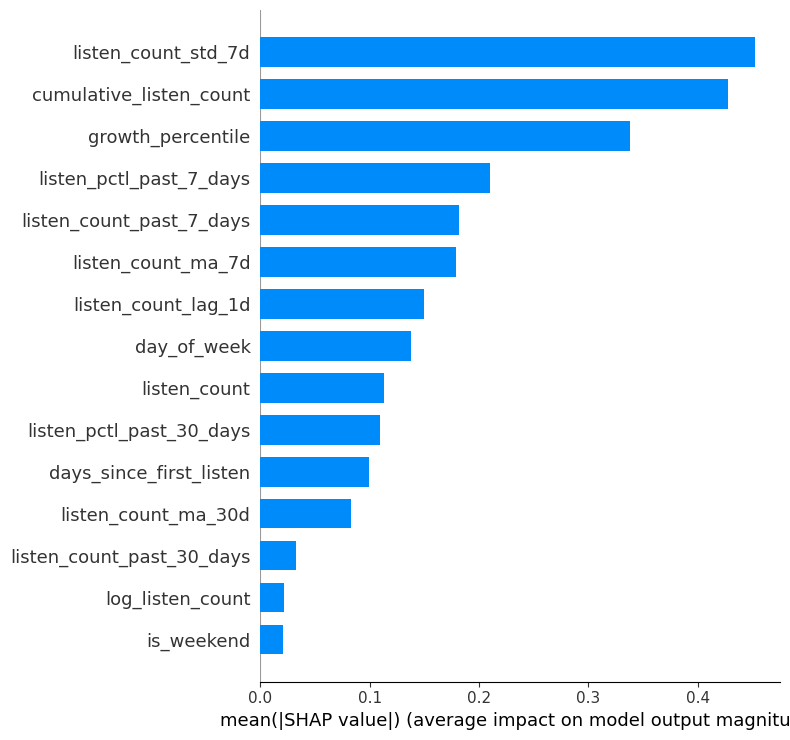


Artist — 30d Classifier


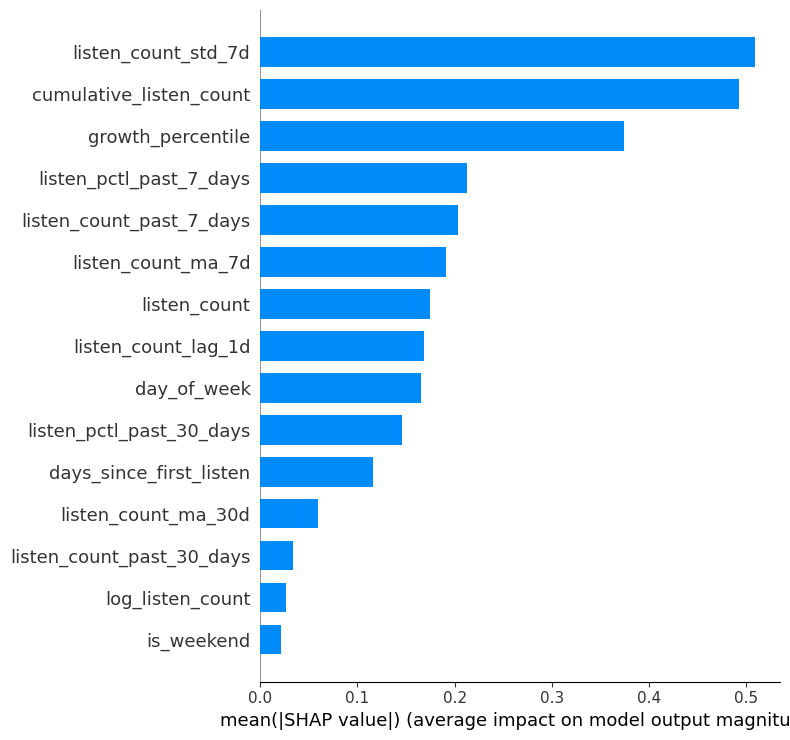


Track — 7d Classifier


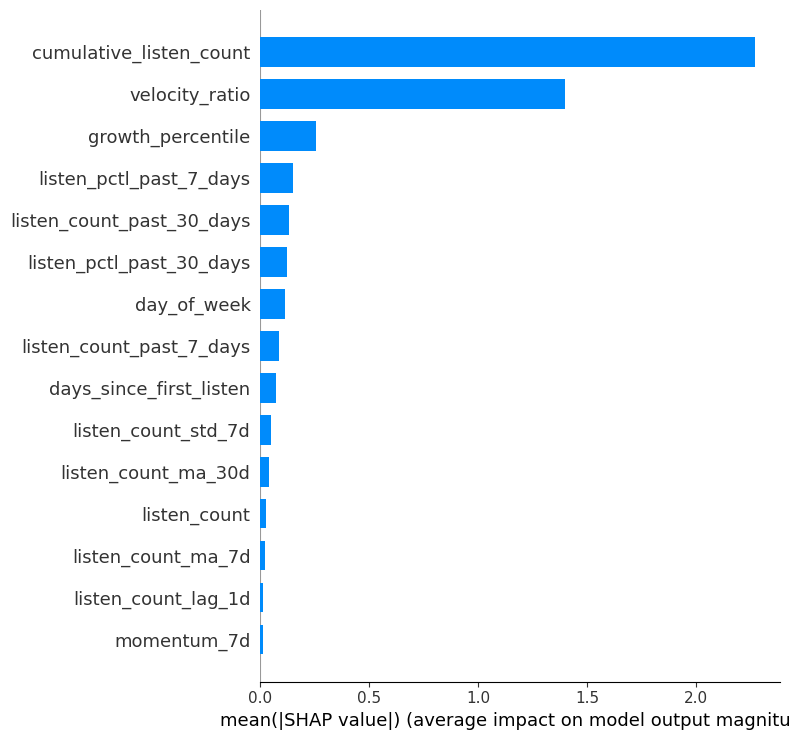


Track — 30d Classifier


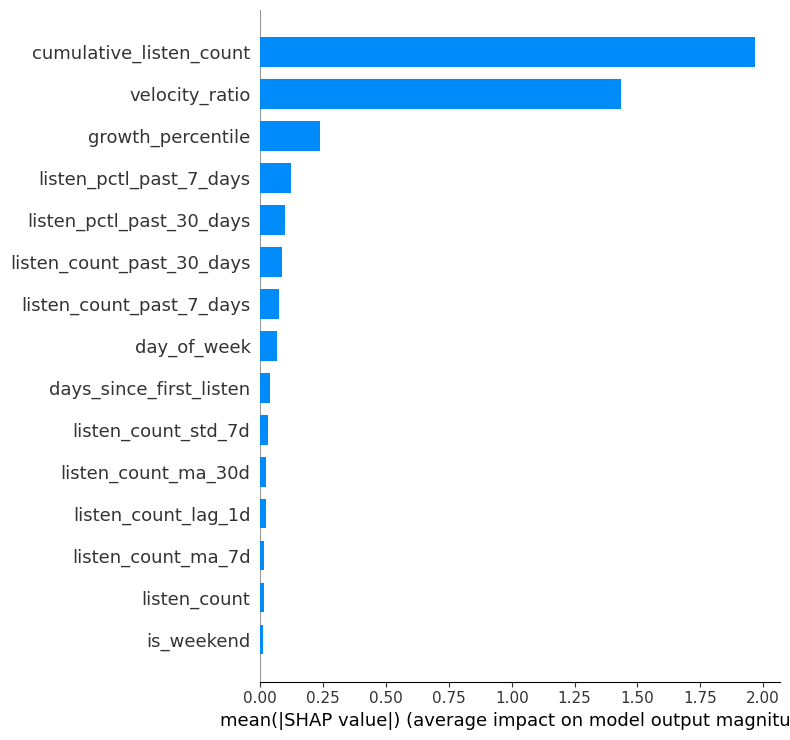

In [17]:
for entity, train_df, _, feat_cols in configs:
    for horizon in ["7d", "30d"]:
        key = (entity, horizon, "clf")
        if key not in xgb_results:
            continue

        model, met, _ = xgb_results[key]
        if model is None or not met:
            print(f"Skipping SHAP for {entity}-{horizon}: model missing or invalid metrics.")
            continue

        if len(train_df) == 0 or len(feat_cols) == 0:
            print(f"Skipping SHAP for {entity}-{horizon}: empty train/features.")
            continue

        X_sample = train_df[feat_cols].fillna(0).sample(n=min(500, len(train_df)), random_state=42)
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_sample)

        print(f"\n{entity.title()} — {horizon} Classifier")
        shap.summary_plot(shap_vals, X_sample, plot_type="bar", max_display=15, show=True)

## Phase 3 — LSTM Sequence Models (PyTorch)

Build sliding-window sequences (T=30 past days → predict label) for each entity. Train LSTM networks for both classification and regression targets.

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {device}")

PyTorch device: cpu


In [19]:
SEQ_LEN = 14  # Shorter context window to make LSTM training feasible on CPU

class TimeSeriesDataset(Dataset):
    """Sliding-window dataset: (SEQ_LEN, n_features) -> target scalar."""

    def __init__(self, df, id_col, feature_cols, target_col, seq_len=SEQ_LEN):
        self.sequences = []
        self.targets = []

        for _, group in df.groupby(id_col):
            group = group.sort_values("day")
            X = group[feature_cols].fillna(0).values.astype(np.float32)
            y = group[target_col].values.astype(np.float32)

            for i in range(seq_len, len(group)):
                self.sequences.append(X[i - seq_len : i])
                self.targets.append(y[i])

        self.sequences = np.array(self.sequences)  # (N, T, F)
        self.targets = np.array(self.targets)      # (N,)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.float32),
            torch.tensor(self.targets[idx], dtype=torch.float32),
        )


class PopularityLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=1, dropout=0.1, task="clf"):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            n_features,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )
        self.head = nn.Linear(hidden_size, 1)
        self.task = task

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        _, (h_n, _) = self.lstm(x)
        out = self.head(h_n[-1])  # last layer's hidden state
        return out.squeeze(-1)

print(f"TimeSeriesDataset and PopularityLSTM defined (SEQ_LEN={SEQ_LEN})")

TimeSeriesDataset and PopularityLSTM defined (SEQ_LEN=14)


In [20]:
def train_lstm(
    train_df,
    test_df,
    id_col,
    feature_cols,
    target_col,
    task="clf",
    epochs=8,
    batch_size=1024,
    lr=1e-3,
    seq_len=SEQ_LEN,
    hidden_size=32,
    num_layers=1,
    dropout=0.1,
    max_train_sequences=200_000,
    seed=42,
):
    """
    Train a lightweight LSTM for feasibility on local hardware.
    task='clf' uses BCEWithLogitsLoss, task='reg' uses MSELoss.
    Returns (model, metrics_dict, test_preds).
    """
    if len(feature_cols) == 0:
        print("  Warning: no features; skipping.")
        return None, {}, np.array([])

    train_ds = TimeSeriesDataset(train_df, id_col, feature_cols, target_col, seq_len=seq_len)
    test_ds = TimeSeriesDataset(test_df, id_col, feature_cols, target_col, seq_len=seq_len)
    print(f"  Train sequences: {len(train_ds):,}  Test sequences: {len(test_ds):,}")

    if len(train_ds) == 0 or len(test_ds) == 0:
        print("  Warning: not enough sequences; skipping.")
        return None, {}, np.array([])

    # Cap training sequences to keep wall-clock time manageable.
    if max_train_sequences and len(train_ds) > max_train_sequences:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(train_ds), size=max_train_sequences, replace=False)
        train_ds.sequences = train_ds.sequences[idx]
        train_ds.targets = train_ds.targets[idx]
        print(f"  Capped train sequences to {len(train_ds):,}")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    n_features = train_ds.sequences.shape[2]
    model = PopularityLSTM(
        n_features,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        task=task,
    ).to(device)

    if task == "clf":
        pos_rate = float(train_ds.targets.mean())
        if pos_rate <= 0 or pos_rate >= 1:
            print("  Warning: training target has a single class; skipping.")
            return None, {}, np.array([])
        pos_weight = torch.tensor([(1 - pos_rate) / max(pos_rate, 1e-6)], device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_loss = float("inf")
    best_state = None
    patience_counter = 0
    early_stop_patience = 4

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                out = model(X_batch)
                val_loss += criterion(out, y_batch).item() * len(y_batch)
        val_loss /= len(test_ds)
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if patience_counter >= early_stop_patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            if task == "clf":
                out = torch.sigmoid(out)
            all_preds.append(out.cpu().numpy())
            all_targets.append(y_batch.numpy())

    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    metrics = {}
    if task == "clf":
        decision_threshold, _ = _best_f1_threshold(targets, preds)
        binary_preds = (preds >= decision_threshold).astype(int)

        has_two_classes = len(np.unique(targets)) > 1
        test_pos_count = int(targets.sum())
        test_size = int(len(targets))
        test_neg_count = int(test_size - test_pos_count)
        train_pos_rate = float(train_ds.targets.mean())

        roc_auc = roc_auc_score(targets, preds) if has_two_classes else float("nan")
        pr_auc = average_precision_score(targets, preds) if test_pos_count > 0 else float("nan")

        baseline_prob = np.full(len(targets), train_pos_rate)
        baseline_pr_auc = average_precision_score(targets, baseline_prob) if test_pos_count > 0 else float("nan")
        baseline_binary = (baseline_prob >= decision_threshold).astype(int)
        baseline_f1 = f1_score(targets, baseline_binary, zero_division=0)

        f1 = f1_score(targets, binary_preds, zero_division=0)
        precision = precision_score(targets, binary_preds, zero_division=0)
        recall = recall_score(targets, binary_preds, zero_division=0)

        metrics = {
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "decision_threshold": decision_threshold,
            "train_pos_rate": train_pos_rate,
            "test_pos_rate": float(targets.mean()) if len(targets) > 0 else float("nan"),
            "test_pos_count": test_pos_count,
            "test_neg_count": test_neg_count,
            "test_size": test_size,
            "baseline_pr_auc": baseline_pr_auc,
            "pr_auc_gain": (pr_auc - baseline_pr_auc) if not np.isnan(pr_auc) and not np.isnan(baseline_pr_auc) else float("nan"),
            "baseline_f1": baseline_f1,
            "f1_gain": f1 - baseline_f1,
        }

        print(
            f"  Test: AUC={metrics['roc_auc']:.4f}  AP={metrics['pr_auc']:.4f}  "
            f"F1={metrics['f1']:.4f}  Prec={metrics['precision']:.4f}  Rec={metrics['recall']:.4f}  "
            f"th={metrics['decision_threshold']:.2f}"
        )
        print(
            f"  Baseline: AP={metrics['baseline_pr_auc']:.4f}  AP_gain={metrics['pr_auc_gain']:.4f}  "
            f"F1_gain={metrics['f1_gain']:.4f}"
        )
    else:
        rmse = np.sqrt(mean_squared_error(targets, preds))
        mae = mean_absolute_error(targets, preds)

        baseline_pred = np.full(len(targets), float(train_ds.targets.mean()))
        baseline_rmse = np.sqrt(mean_squared_error(targets, baseline_pred))
        baseline_mae = mean_absolute_error(targets, baseline_pred)

        binary_preds = (preds >= 0.95).astype(int)
        binary_targets = (targets >= 0.95).astype(int)
        baseline_binary = (baseline_pred >= 0.95).astype(int)

        has_two_binary = len(np.unique(binary_targets)) > 1
        test_pos_count = int(binary_targets.sum())

        roc_auc_thresholded = roc_auc_score(binary_targets, preds) if has_two_binary else float("nan")
        pr_auc_thresholded = average_precision_score(binary_targets, preds) if test_pos_count > 0 else float("nan")
        baseline_pr_auc_thresholded = average_precision_score(binary_targets, baseline_pred) if test_pos_count > 0 else float("nan")

        f1_thresholded = f1_score(binary_targets, binary_preds, zero_division=0)
        baseline_f1_thresholded = f1_score(binary_targets, baseline_binary, zero_division=0)

        metrics = {
            "rmse": rmse,
            "mae": mae,
            "baseline_rmse": baseline_rmse,
            "baseline_mae": baseline_mae,
            "rmse_improvement": baseline_rmse - rmse,
            "mae_improvement": baseline_mae - mae,
            "roc_auc_thresholded": roc_auc_thresholded,
            "pr_auc_thresholded": pr_auc_thresholded,
            "baseline_pr_auc_thresholded": baseline_pr_auc_thresholded,
            "pr_auc_gain": (
                pr_auc_thresholded - baseline_pr_auc_thresholded
                if not np.isnan(pr_auc_thresholded) and not np.isnan(baseline_pr_auc_thresholded)
                else float("nan")
            ),
            "f1_thresholded": f1_thresholded,
            "baseline_f1_thresholded": baseline_f1_thresholded,
            "f1_gain": f1_thresholded - baseline_f1_thresholded,
            "test_pos_count": test_pos_count,
        }

        print(
            f"  Test: RMSE={metrics['rmse']:.4f}  MAE={metrics['mae']:.4f}  "
            f"th-AUC={metrics['roc_auc_thresholded']:.4f}  th-AP={metrics['pr_auc_thresholded']:.4f}"
        )
        print(
            f"  Baseline: RMSE={metrics['baseline_rmse']:.4f}  RMSE_gain={metrics['rmse_improvement']:.4f}  "
            f"th-AP_gain={metrics['pr_auc_gain']:.4f}"
        )

    return model, metrics, preds


print("train_lstm() defined")

train_lstm() defined


### Train LSTM models (track-only, budgeted)
To keep runtime practical, we train only track models and use a reduced training budget (shorter sequence length, capped samples, fewer epochs).

In [21]:
lstm_results = {}  # key: (entity, horizon, model_type) -> (model, metrics, preds)

# Track-only LSTM to keep training feasible in local runtime.
lstm_configs = [
    ("track", trk_train, trk_test, "recording_id", trk_features),
]

lstm_train_params = {
    "epochs": 6,
    "batch_size": 1024,
    "lr": 1e-3,
    "seq_len": 14,
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.1,
    "max_train_sequences": 200_000,
}

lstm_attempted = 0
lstm_successful = 0

for entity, train_df, test_df, id_col, feat_cols in lstm_configs:
    if len(train_df) == 0 or len(test_df) == 0 or len(feat_cols) == 0:
        print(f"Skipping {entity}: empty train/test or no features.")
        continue

    for horizon in ["7d", "30d"]:
        clf_target = f"is_popular_{horizon}"
        reg_target = f"future_growth_pctl_{horizon}"

        print(f"\n{'='*60}")
        print(f"LSTM Classifier - {entity} - {horizon}")
        print(f"{'='*60}")
        lstm_attempted += 1
        m, met, preds = train_lstm(
            train_df,
            test_df,
            id_col,
            feat_cols,
            clf_target,
            task="clf",
            **lstm_train_params,
        )
        if m is not None and bool(met):
            lstm_results[(entity, horizon, "clf")] = (m, met, preds)
            lstm_successful += 1
        else:
            print("  Classifier not stored (training skipped or invalid metrics).")

        print(f"\nLSTM Regressor - {entity} - {horizon}")
        print(f"{'-'*60}")
        lstm_attempted += 1
        m, met, preds = train_lstm(
            train_df,
            test_df,
            id_col,
            feat_cols,
            reg_target,
            task="reg",
            **lstm_train_params,
        )
        if m is not None and bool(met):
            lstm_results[(entity, horizon, "reg")] = (m, met, preds)
            lstm_successful += 1
        else:
            print("  Regressor not stored (training skipped or invalid metrics).")

print(f"\nLSTM attempts: {lstm_attempted}")
print(f"LSTM successfully trained: {lstm_successful}")
print(f"LSTM entries stored: {len(lstm_results)}")


LSTM Classifier - track - 7d
  Train sequences: 1,003  Test sequences: 0
  Classifier not stored (training skipped or invalid metrics).

LSTM Regressor - track - 7d
------------------------------------------------------------
  Train sequences: 1,003  Test sequences: 0
  Regressor not stored (training skipped or invalid metrics).

LSTM Classifier - track - 30d
  Train sequences: 1,003  Test sequences: 0
  Classifier not stored (training skipped or invalid metrics).

LSTM Regressor - track - 30d
------------------------------------------------------------
  Train sequences: 1,003  Test sequences: 0
  Regressor not stored (training skipped or invalid metrics).

LSTM attempts: 4
LSTM successfully trained: 0
LSTM entries stored: 0


In [22]:
# Save LSTM models (PyTorch state_dicts + metrics)
lstm_path = MODELS_DIR / "lstm_models.pt"
lstm_save_data = {}

for key, (model, metrics, preds) in lstm_results.items():
    if model is not None and bool(metrics):
        lstm_save_data[key] = {
            "state_dict": model.state_dict(),
            "metrics": metrics,
            # Store architecture params for reconstruction
            "n_features": model.lstm.input_size,
            "hidden_size": model.lstm.hidden_size,
            "num_layers": model.lstm.num_layers,
            "task": model.task,
        }

torch.save(lstm_save_data, lstm_path)
print(f"LSTM entries available: {len(lstm_results)}")
print(f"LSTM models saved (trained only): {len(lstm_save_data)}")
print(f"Saved to: {lstm_path}")

# To load models later (skip training):
# lstm_save_data = torch.load(lstm_path, map_location=device)
# lstm_results = {}
# for key, data in lstm_save_data.items():
#     model = PopularityLSTM(
#         data["n_features"],
#         data["hidden_size"],
#         data["num_layers"],
#         task=data["task"]
#     ).to(device)
#     model.load_state_dict(data["state_dict"])
#     model.eval()
#     lstm_results[key] = (model, data["metrics"], None)  # preds not saved
# print(f"Loaded {len(lstm_results)} LSTM models from {lstm_path}")

LSTM entries available: 0
LSTM models saved (trained only): 0
Saved to: ../models/lstm_models.pt


## Phase 4 — Evaluation & Comparison

Side-by-side metrics table, ROC curves, precision-recall curves, and top-N predicted rising entities vs actuals.

In [23]:
# Build comparison metrics table with reliability + baseline checks
rows = []
for key_set, label in [(xgb_results, "XGBoost"), (lstm_results, "LSTM")]:
    for (entity, horizon, mtype), (_, metrics, _) in key_set.items():
        if not metrics:
            continue
        row = {"Model": label, "Entity": entity, "Horizon": horizon, "Type": mtype}
        row.update(metrics)
        rows.append(row)

metrics_df = pd.DataFrame(rows)

if metrics_df.empty:
    print("No metrics available yet. Run training cells first.")
else:
    # Reliability: classifier evaluation is unreliable with too few positives/negatives in test.
    metrics_df["evaluation_reliable"] = True
    clf_mask = metrics_df["Type"] == "clf"

    if {"test_pos_count", "test_neg_count"}.issubset(metrics_df.columns):
        metrics_df.loc[clf_mask, "evaluation_reliable"] = (
            (metrics_df.loc[clf_mask, "test_pos_count"].fillna(0) >= 10)
            & (metrics_df.loc[clf_mask, "test_neg_count"].fillna(0) >= 10)
        )
    elif "test_pos_count" in metrics_df.columns:
        metrics_df.loc[clf_mask, "evaluation_reliable"] = (
            metrics_df.loc[clf_mask, "test_pos_count"].fillna(0) >= 10
        )

    # Baseline pass criteria
    metrics_df["beats_baseline"] = False

    if "pr_auc_gain" in metrics_df.columns:
        metrics_df.loc[clf_mask, "beats_baseline"] = (
            metrics_df.loc[clf_mask, "pr_auc_gain"].fillna(-np.inf) > 0
        )

    reg_mask = metrics_df["Type"] == "reg"
    if "rmse_improvement" in metrics_df.columns:
        metrics_df.loc[reg_mask, "beats_baseline"] = (
            metrics_df.loc[reg_mask, "rmse_improvement"].fillna(-np.inf) > 0
        )

    metrics_df["status"] = np.where(
        metrics_df["evaluation_reliable"] & metrics_df["beats_baseline"],
        "PASS",
        "NEEDS_WORK",
    )

    display_cols = [
        "Model", "Entity", "Horizon", "Type", "status",
        "evaluation_reliable", "beats_baseline",
        "roc_auc", "pr_auc", "f1", "precision", "recall",
        "rmse", "mae",
        "baseline_pr_auc", "pr_auc_gain",
        "baseline_rmse", "rmse_improvement",
        "decision_threshold", "test_pos_count", "test_neg_count", "test_size",
    ]
    display_cols = [c for c in display_cols if c in metrics_df.columns]

    display(
        metrics_df[display_cols]
        .sort_values(["Model", "Entity", "Horizon", "Type"])
        .reset_index(drop=True)
        .round(4)
    )

    print("\nStatus summary:")
    print(metrics_df["status"].value_counts(dropna=False).to_string())

    unreliable = metrics_df[~metrics_df["evaluation_reliable"]]
    if len(unreliable) > 0:
        cols = [c for c in ["Model", "Entity", "Horizon", "Type", "test_pos_count", "test_neg_count", "test_size"] if c in unreliable.columns]
        print("\nUnreliable evaluations (insufficient class coverage in test):")
        print(unreliable[cols].to_string(index=False))

,Model,Entity,Horizon,Type,status,evaluation_reliable,beats_baseline,roc_auc,pr_auc,f1,...,rmse,mae,baseline_pr_auc,pr_auc_gain,baseline_rmse,rmse_improvement,decision_threshold,test_pos_count,test_neg_count,test_size
0,XGBoost,artist,30d,clf,PASS,True,True,0.7399,0.0671,0.1009,...,NaN,NaN,0.0254,0.0417,NaN,NaN,0.75,180,6905.0,7085.0
1,XGBoost,artist,30d,reg,PASS,True,True,NaN,NaN,NaN,...,0.1665,0.1400,NaN,0.0359,0.1867,0.0202,NaN,166,NaN,NaN
2,XGBoost,artist,7d,clf,PASS,True,True,0.7432,0.0708,0.1016,...,NaN,NaN,0.0254,0.0454,NaN,NaN,0.70,180,6905.0,7085.0
3,XGBoost,artist,7d,reg,PASS,True,True,NaN,NaN,NaN,...,0.1746,0.1479,NaN,0.0355,0.1869,0.0122,NaN,166,NaN,NaN
4,XGBoost,track,30d,clf,PASS,True,True,0.9635,0.3922,0.0000,...,NaN,NaN,0.0160,0.3762,NaN,NaN,0.85,16,985.0,1001.0
5,XGBoost,track,30d,reg,PASS,True,True,NaN,NaN,NaN,...,0.0503,0.0343,NaN,NaN,0.0957,0.0454,NaN,0,NaN,NaN
6,XGBoost,track,7d,clf,PASS,True,True,0.9515,0.3893,0.1111,...,NaN,NaN,0.0160,0.3733,NaN,NaN,0.70,16,985.0,1001.0
7,XGBoost,track,7d,reg,PASS,True,True,NaN,NaN,NaN,...,0.0514,0.0384,NaN,NaN,0.0972,0.0458,NaN,0,NaN,NaN



Status summary:
status
PASS    8


### ROC & Precision-Recall Curves (Classifiers only)

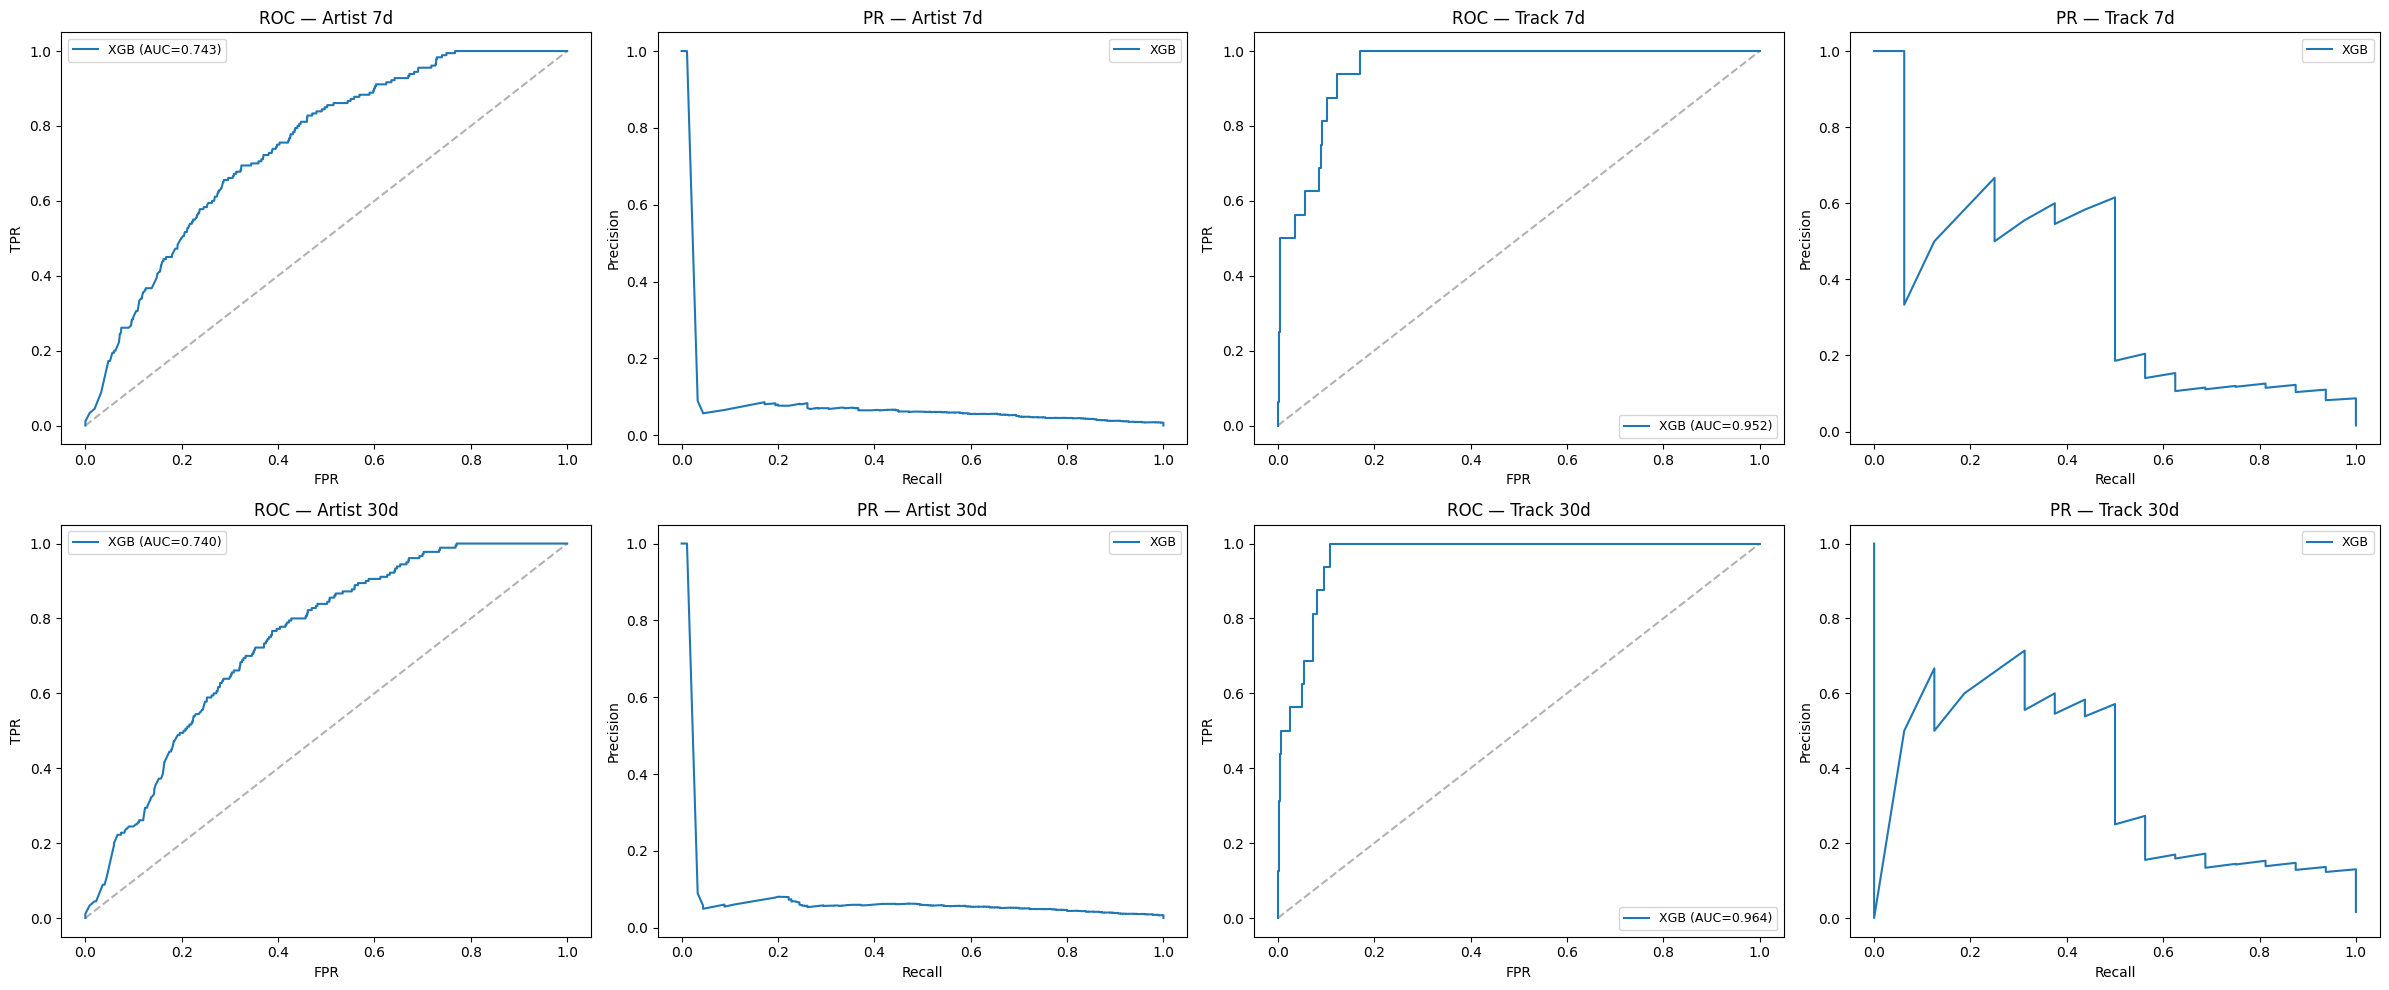

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

for col_offset, (entity, _, test_df, feat_cols) in enumerate(configs):
    for row, horizon in enumerate(["7d", "30d"]):
        target_col = f"is_popular_{horizon}"

        # --- ROC ---
        ax_roc = axes[row][col_offset * 2]
        ax_roc.set_title(f"ROC — {entity.title()} {horizon}")
        ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.3)

        # XGBoost
        xgb_proba = xgb_results[(entity, horizon, "clf")][2]
        xgb_y = test_df[target_col].values

        # Check if both classes present (need for ROC/AUC)
        n_classes = len(np.unique(xgb_y))
        if n_classes > 1:
            fpr, tpr, _ = roc_curve(xgb_y, xgb_proba)
            ax_roc.plot(fpr, tpr, label=f"XGB (AUC={roc_auc_score(xgb_y, xgb_proba):.3f})")
        else:
            ax_roc.text(
                0.5,
                0.5,
                f"Only one class in test set\n({int(xgb_y[0])})",
                ha="center",
                va="center",
                transform=ax_roc.transAxes,
            )

        # LSTM (optional; may be track-only)
        lstm_y = np.array([])
        lstm_key = (entity, horizon, "clf")
        if lstm_key in lstm_results and len(lstm_results[lstm_key][2]) > 0:
            lstm_preds = lstm_results[lstm_key][2]
            id_col = "artist_mbid" if entity == "artist" else "recording_id"
            lstm_ds = TimeSeriesDataset(test_df, id_col, feat_cols, target_col, seq_len=SEQ_LEN)
            lstm_y = lstm_ds.targets

            if len(np.unique(lstm_y)) > 1 and len(lstm_preds) == len(lstm_y):
                fpr2, tpr2, _ = roc_curve(lstm_y, lstm_preds)
                ax_roc.plot(fpr2, tpr2, label=f"LSTM (AUC={roc_auc_score(lstm_y, lstm_preds):.3f})")

        ax_roc.legend(fontsize=9)
        ax_roc.set_xlabel("FPR")
        ax_roc.set_ylabel("TPR")

        # --- Precision-Recall ---
        ax_pr = axes[row][col_offset * 2 + 1]
        ax_pr.set_title(f"PR — {entity.title()} {horizon}")

        if n_classes > 1:
            prec, rec, _ = precision_recall_curve(xgb_y, xgb_proba)
            ax_pr.plot(rec, prec, label="XGB")
        else:
            ax_pr.text(
                0.5,
                0.5,
                f"Only one class in test set\n({int(xgb_y[0])})",
                ha="center",
                va="center",
                transform=ax_pr.transAxes,
            )

        if len(lstm_y) > 0 and lstm_key in lstm_results and len(np.unique(lstm_y)) > 1:
            lstm_preds = lstm_results[lstm_key][2]
            if len(lstm_preds) == len(lstm_y):
                prec2, rec2, _ = precision_recall_curve(lstm_y, lstm_preds)
                ax_pr.plot(rec2, prec2, label="LSTM")

        ax_pr.legend(fontsize=9)
        ax_pr.set_xlabel("Recall")
        ax_pr.set_ylabel("Precision")

plt.tight_layout()
plt.show()

### Top-N Predicted Rising Entities vs Actual
Show the top 20 entities predicted most likely to be "popular" and whether they actually were.

In [25]:
TOP_N = 20

for entity, _, test_df, feat_cols in configs:
    id_col = "artist_mbid" if entity == "artist" else "recording_id"
    for horizon in ["7d", "30d"]:
        target_col = f"is_popular_{horizon}"
        proba = xgb_results[(entity, horizon, "clf")][2]

        result = test_df[[id_col, "day", target_col]].copy()
        result["xgb_score"] = proba

        # Aggregate: mean predicted score per entity
        entity_scores = (
            result.groupby(id_col)
            .agg(
                mean_xgb_score=("xgb_score", "mean"),
                actually_popular=(target_col, "max"),
                n_days=("day", "count"),
            )
            .sort_values("mean_xgb_score", ascending=False)
            .head(TOP_N)
        )

        hit_rate = entity_scores["actually_popular"].mean()
        prevalence = result[target_col].mean()
        lift = (hit_rate / prevalence) if prevalence > 0 else float("nan")

        print(f"\n{entity.title()} - {horizon}: Top {TOP_N} predicted")
        print(f"  Hit rate: {100*hit_rate:.1f}%")
        print(f"  Test-set prevalence: {100*prevalence:.1f}%")
        print(f"  Lift vs random baseline: {lift:.2f}x")

        display(entity_scores.round(4))


Artist - 7d: Top 20 predicted
  Hit rate: 15.0%
  Test-set prevalence: 2.5%
  Lift vs random baseline: 5.90x


,mean_xgb_score,actually_popular,n_days
artist_mbid,,,
e4d13005-5201-4aa8-ab9f-d2d1035f1ae7,0.9871,1,1
85ec6868-f1cf-4339-8274-1423f8f73146,0.9616,1,1
4724214c-d190-4db4-a49e-fcdfb3a0db5b,0.9431,0,1
656de0f0-d5cb-455f-bdf6-4f51b8d64a2c,0.9431,1,1
251a4779-72cd-4482-b9ca-cbd89bc1e165,0.9431,0,1
b7639749-d40b-44a5-b04a-cb15599a5956,0.9431,0,1
7e14cf06-532b-4789-8c03-5aa13da4f6f3,0.9431,0,1
0b84d70a-d485-4d08-8372-2db07f0aa24b,0.9431,0,1
f4a3edfb-1350-414f-a694-0e309d3a6602,0.9431,0,1



Artist - 30d: Top 20 predicted
  Hit rate: 15.0%
  Test-set prevalence: 2.5%
  Lift vs random baseline: 5.90x


,mean_xgb_score,actually_popular,n_days
artist_mbid,,,
e4d13005-5201-4aa8-ab9f-d2d1035f1ae7,0.9952,1,1
85ec6868-f1cf-4339-8274-1423f8f73146,0.9824,1,1
656de0f0-d5cb-455f-bdf6-4f51b8d64a2c,0.9510,1,1
4883523d-fc0e-4d0d-802c-91379e767083,0.9510,0,1
c250041c-a4d5-49f9-8400-c9575721b2dc,0.9510,0,1
8a07d810-3d55-4426-a1f6-55f0a68f1dc6,0.9510,0,1
484cabf9-4ded-4498-9444-e58251b9bba3,0.9510,0,1
484a1d40-0fb9-4768-acff-b570cedaacb4,0.9510,0,1
d6cd2165-7877-4ca7-ace9-34dacadaf393,0.9510,0,1



Track - 7d: Top 20 predicted
  Hit rate: 40.0%
  Test-set prevalence: 1.6%
  Lift vs random baseline: 25.03x


,mean_xgb_score,actually_popular,n_days
recording_id,,,
_Magia głębokiego snu,0.8679,1,1
_XO (Only If You Say Yes),0.7185,0,1
_Safety Zone,0.6789,1,1
_nOthIng at All,0.6423,0,2
_Music Box : Reflection,0.5955,1,1
_= (Equal Sign),0.5955,1,1
_hEAlThy haBIt,0.5709,0,2
_What if…,0.5678,1,1
_Whatever Floats Your Boat Will Definitely Sink My Ship,0.5595,1,1



Track - 30d: Top 20 predicted
  Hit rate: 40.0%
  Test-set prevalence: 1.6%
  Lift vs random baseline: 25.03x


,mean_xgb_score,actually_popular,n_days
recording_id,,,
_Magia głębokiego snu,0.8264,1,1
_angel wings,0.7792,0,2
_What if…,0.7690,1,1
_Safety Zone,0.6829,1,1
_Music Box : Reflection,0.6592,1,1
_= (Equal Sign),0.6592,1,1
_Human (feat. Jesse & Joy),0.6239,1,1
_Plastic Cigarette,0.6220,0,1
_Whatever Floats Your Boat Will Definitely Sink My Ship,0.6196,1,1


### Time Series Visualization: Top 20 Predicted Tracks (30d Model)

Visualize actual listen counts over time for the top 20 tracks predicted by the **XGBoost track 30d classifier**, showing:
- Historical trajectory (last ~2 months of training window)
- Actual performance in test window
- Model predictions for popularity (XGBoost classifier + regressor)

Top 20 tracks selected by mean XGB 30d classifier score:
                                                    mean_xgb_30d_score  \
recording_id                                                             
_Magia głębokiego snu                                           0.8264   
_angel wings                                                    0.7792   
_What if…                                                       0.7690   
_Safety Zone                                                    0.6829   
_Music Box : Reflection                                         0.6592   
_= (Equal Sign)                                                 0.6592   
_Human (feat. Jesse & Joy)                                      0.6239   
_Plastic Cigarette                                              0.6220   
_Whatever Floats Your Boat Will Definitely Sink...              0.6196   
_XO (Only If You Say Yes)                                       0.6023   
_hEAlThy haBIt                                         

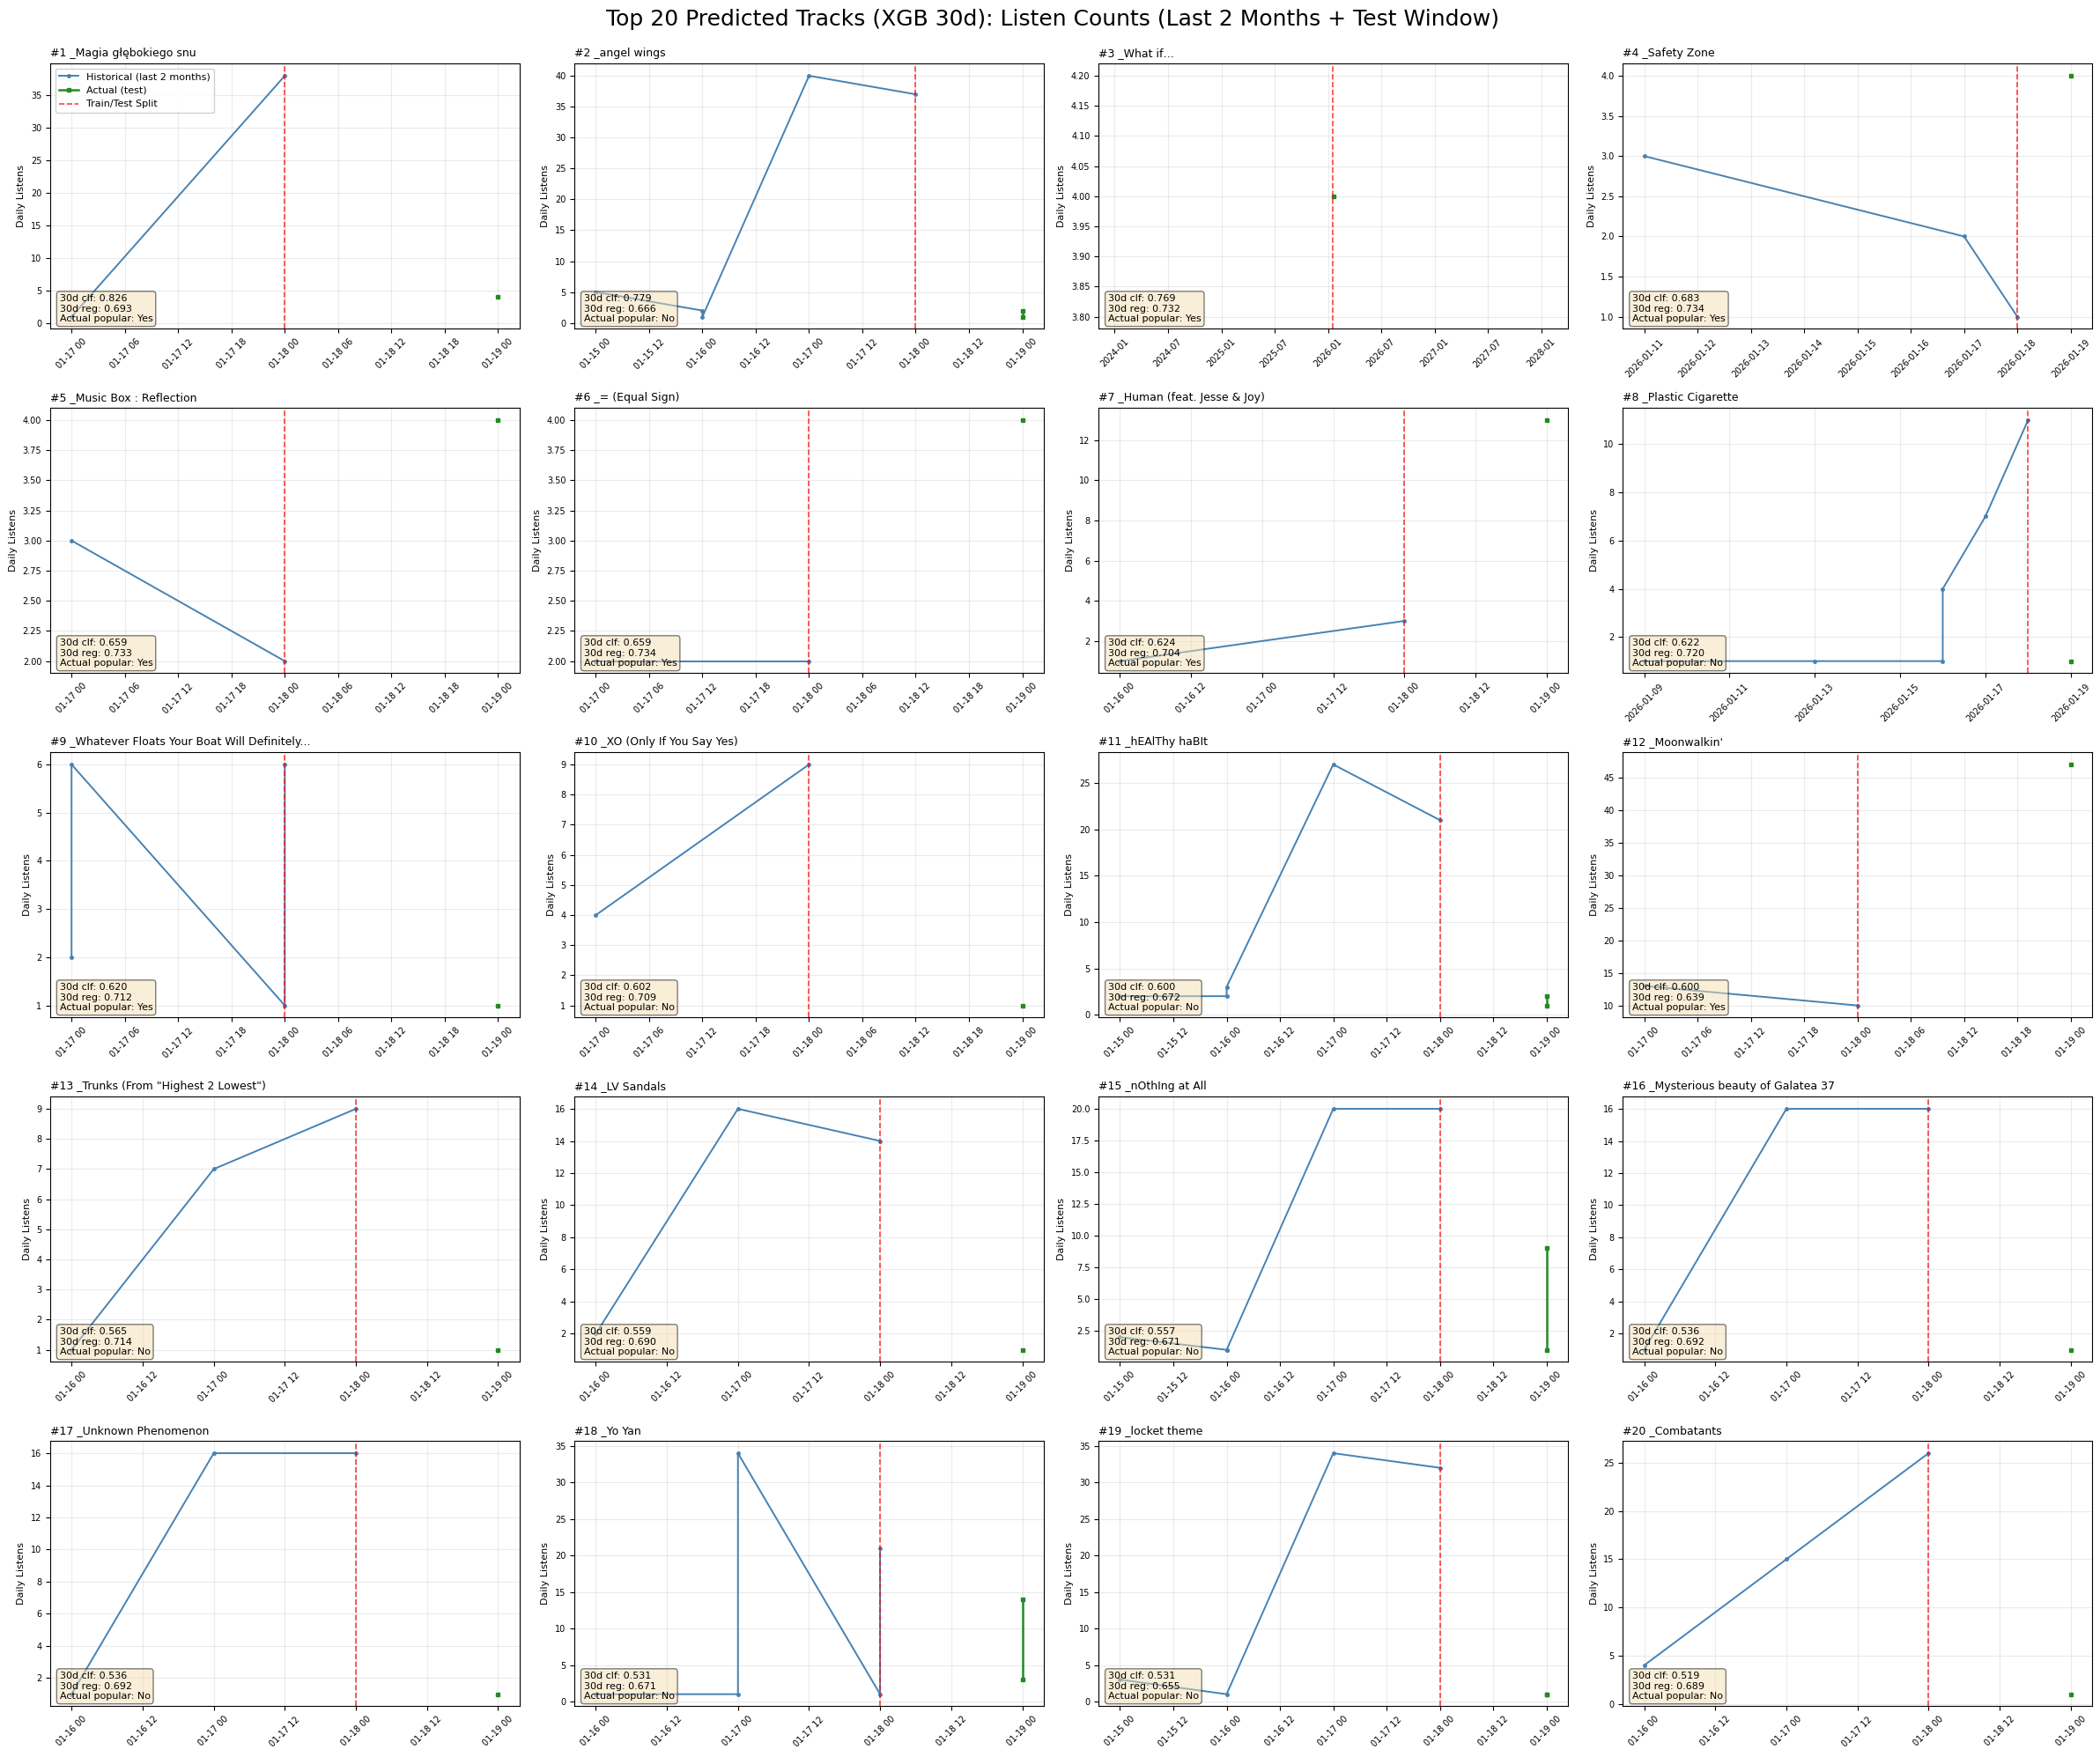


Visualization complete for top 20 predicted tracks (30d model).


In [26]:
# Select top 20 tracks by predicted score from the track 30d classifier
TOP_K_PLOTS = 20

track_30d_proba = xgb_results[("track", "30d", "clf")][2]
track_30d_reg = xgb_results[("track", "30d", "reg")][2]

trk_test_with_preds = trk_test.copy()
trk_test_with_preds["xgb_30d_clf_score"] = track_30d_proba
trk_test_with_preds["xgb_30d_reg_pred"] = track_30d_reg

# Aggregate per track and pick top 20 by mean predicted 30d popularity score
top_tracks_df = (
    trk_test_with_preds
    .groupby("recording_id")
    .agg(
        mean_xgb_30d_score=("xgb_30d_clf_score", "mean"),
        mean_xgb_30d_reg=("xgb_30d_reg_pred", "mean"),
        actually_popular_30d=("is_popular_30d", "max"),
        n_test_days=("day", "count"),
    )
    .sort_values("mean_xgb_30d_score", ascending=False)
    .head(TOP_K_PLOTS)
)
top_tracks = top_tracks_df.index.tolist()

print("Top 20 tracks selected by mean XGB 30d classifier score:")
print(top_tracks_df[["mean_xgb_30d_score", "actually_popular_30d", "n_test_days"]].round(4))

# Time boundaries
train_max_day = trk_train["day"].max()
test_min_day = trk_test["day"].min()
test_max_day = trk_test["day"].max()
history_start = train_max_day - pd.Timedelta(days=60)

print(f"\nTrain/test split: {train_max_day}")
print(f"Test window: {test_min_day} to {test_max_day}")
print(f"Showing training data from: {history_start} onwards")

# Plot as 5x4 grid (20 tracks)
nrows, ncols = 5, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(24, 20), sharex=False)
axes = axes.flatten()
fig.suptitle(
    "Top 20 Predicted Tracks (XGB 30d): Listen Counts (Last 2 Months + Test Window)",
    fontsize=18,
    y=0.995,
)

for idx, track_id in enumerate(top_tracks):
    ax = axes[idx]

    # Historical data (last ~2 months before split)
    track_train = (
        trk_train[
            (trk_train["recording_id"] == track_id)
            & (trk_train["day"] >= history_start)
        ]
        .sort_values("day")
    )

    # Test data with predictions
    track_test = (
        trk_test_with_preds[trk_test_with_preds["recording_id"] == track_id]
        .sort_values("day")
    )

    if len(track_train) > 0:
        ax.plot(
            track_train["day"],
            track_train["listen_count"],
            color="steelblue",
            linewidth=1.4,
            marker="o",
            markersize=2.5,
            label="Historical (last 2 months)",
        )

    if len(track_test) > 0:
        ax.plot(
            track_test["day"],
            track_test["listen_count"],
            color="forestgreen",
            linewidth=1.8,
            marker="s",
            markersize=3,
            label="Actual (test)",
        )

    ax.axvline(
        train_max_day,
        color="red",
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        label="Train/Test Split",
    )

    # Annotation with model summary for this track
    stats = top_tracks_df.loc[track_id]
    pred_text = (
        f"30d clf: {stats['mean_xgb_30d_score']:.3f}\n"
        f"30d reg: {stats['mean_xgb_30d_reg']:.3f}\n"
        f"Actual popular: {'Yes' if int(stats['actually_popular_30d']) == 1 else 'No'}"
    )
    ax.text(
        0.02,
        0.02,
        pred_text,
        transform=ax.transAxes,
        fontsize=8,
        va="bottom",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    track_display = track_id if len(track_id) <= 45 else track_id[:42] + "..."
    ax.set_title(f"#{idx+1} {track_display}", fontsize=9, loc="left")
    ax.set_ylabel("Daily Listens", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, alpha=0.25)

    # Keep legend only on first panel to reduce clutter
    if idx == 0:
        ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

# Hide any unused axes (defensive)
for j in range(len(top_tracks), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

print("\nVisualization complete for top 20 predicted tracks (30d model).")